# 🏙️ Hitkavyam — Varanasi MaaS Analysis Pipeline
> **Three-phase analysis:** Data Audit & BE Archetypes → Spatial Analysis → Behavioural Modelling  
> **Best-of-both synthesis** — combines structural rigour of Phase1_Explo with the full pipeline of Hitkavyam_v2.  
> Run cells **top-to-bottom**. Upload your two CSV files and the GeoJSON when prompted.

**Key upgrades vs previous version:**
- ✅ MinMaxScaler + multicollinearity fix for BE clustering (Phase 1)
- ✅ Silhouette validation + dynamic archetype labelling (Phase 1)
- ✅ Corridor_Demand_Volume bridges Phase 2 → Phase 3 (Phase 2)
- ✅ All top-20 corridors overlaid on bus-route map, colour-coded by gap (Phase 2)
- ✅ True CFA via `factor_analyzer` — not sklearn EFA (Phase 3)
- ✅ Income as dummy variables, Car as explicit MNL baseline (Phase 3)
- ✅ Robust ordinal logit: variance checks, Ghat-Core BE-dummy drop (Phase 3)
- ✅ Research conclusions with synthesis visualisation (Phase 4)

**Outputs saved to `outputs/` folder — download them at the end.**

## ⚙️ Cell 1 — Install dependencies
*Run once per Colab session. Takes ~90 seconds.*

In [ ]:
!pip install h3 statsmodels scikit-learn geopandas folium factor_analyzer --quiet
print('✅ Dependencies ready')

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.8/42.8 kB 2.0 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 18.1 MB/s eta 0:00:00
✅ Dependencies ready


## 📂 Cell 2 — Upload data files
Upload **VNS_SURVEY_IND.csv**, **VNS_SURVEY_OD.csv**, and **decoded_bus_routes.geojson** when prompted.

In [ ]:
from google.colab import files
import io, os, json

print('Please upload VNS_SURVEY_IND.csv, VNS_SURVEY_OD.csv, and decoded_bus_routes.geojson')
uploaded = files.upload()

for fname, data in uploaded.items():
    with open(fname, 'wb') as f:
        f.write(data)
    print(f'  Saved: {fname} ({len(data):,} bytes)')

# ── Detect correct filenames (handles spaces and variants) ─────────────────
def find_file(candidates):
    for c in candidates:
        if os.path.exists(c): return c
    raise FileNotFoundError(f'None of {candidates} found')

IND_PATH     = find_file(['VNS_SURVEY_IND.csv','VNS SURVEY IND.csv'])
OD_PATH      = find_file(['VNS_SURVEY_OD.csv','VNS SURVEY OD.csv','VNS SURVEY OD (2).csv'])
GEOJSON_PATH = find_file(['decoded_bus_routes.geojson'])
OUT_DIR      = 'outputs/'
os.makedirs(OUT_DIR, exist_ok=True)
print(f'\n✅ IND: {IND_PATH} | OD: {OD_PATH} | GeoJSON: {GEOJSON_PATH}')
print('outputs/ directory created.')

Please upload VNS_SURVEY_IND.csv, VNS_SURVEY_OD.csv, and decoded_bus_routes.geojson



✅ IND: VNS SURVEY IND.csv | OD: VNS SURVEY OD.csv | GeoJSON: decoded_bus_routes.geojson
outputs/ directory created.


## 🔧 Cell 3 — Shared imports & helpers
*Must run before any phase cell.*

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import warnings, os, json
from functools import reduce
warnings.filterwarnings('ignore')
%matplotlib inline
plt.rcParams.update({'figure.dpi': 120, 'figure.facecolor': 'white'})

# ── Likert map ────────────────────────────────────────────────────────────
LIKERT_MAP = {
    'Strongly Disagree': 1, 'Disagree': 2, 'Neutral': 3,
    'Agree': 4, 'Strongly Agree': 5,
}

# ── TAM + TPB construct definitions ──────────────────────────────────────
CFA_CONSTRUCTS = {
    'PU':   ['PTS','PTW','PTJ','PTSR','PTND'],
    'PEOU': ['PEOU1','PEOU2'],
    'ATT':  ['PTC','PTWI','PTCD','PTVN','PTVC'],
    'SN':   ['PTIU','PTH','PTPI','PTRS'],
    'PBC':  ['ITU1','ITU2'],
    'PR':   ['PR1','PR2','PR3','PR4'],
    'AW':   ['AW1','AW2','AW3'],
    'FC':   ['FC1','FC2'],
    'PE':   ['PE1','PE2','PE3'],
}

def encode_likert(df, mapping=LIKERT_MAP):
    out = df.copy()
    cols = [c for grp in CFA_CONSTRUCTS.values() for c in grp if c in out.columns]
    for c in cols:
        if out[c].dtype == object:
            out[c] = out[c].map(mapping)
    return out

def cronbach_alpha(df, items):
    sub = df[items].dropna()
    if sub.shape[1] < 2 or len(sub) < 5: return np.nan
    k = sub.shape[1]
    var_total = sub.sum(axis=1).var(ddof=1)
    if var_total == 0: return np.nan
    return (k/(k-1))*(1 - sub.var(axis=0, ddof=1).sum()/var_total)

print('✅ Shared helpers loaded')

---
# 📊 PHASE 1 — Data Audit & Built-Environment Archetypes
**Tasks:** merge IND+OD · null check · Cronbach α · TLFD curves · K-Means BE archetypes

**Key improvements:** LEFT join · MinMaxScaler · multicollinearity fix · silhouette validation · dynamic archetype labelling

### 1A · Load, merge & null-check

IND  → 3,246 rows × 75 cols
OD   → 16,230 rows × 9 cols
Merged → 16,230 rows × 83 cols

── Null audit (key columns) ──
                       null_count  pct
Walkability_Score               0  0.0
Road_Density_Category           0  0.0
Land_Use_Entropy                0  0.0
Distance_to_CBD_km              0  0.0
Income                          0  0.0
Mode_to_Work                    0  0.0
Shift                           0  0.0
Infacc                          0  0.0
Latitude_WGS84                  0  0.0
Longitude_WGS84                 0  0.0


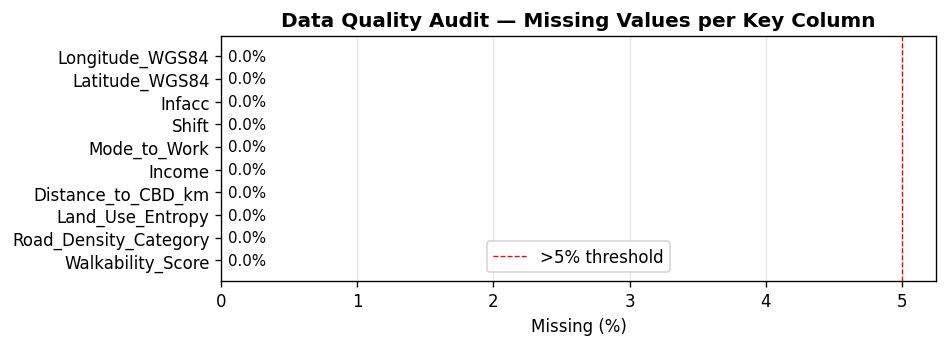


✅ 1A complete — IND & OD loaded, null audit saved


In [ ]:
ind_raw = pd.read_csv(IND_PATH)
od_raw  = pd.read_csv(OD_PATH)

print(f'IND  → {len(ind_raw):,} rows × {ind_raw.shape[1]} cols')
print(f'OD   → {len(od_raw):,} rows × {od_raw.shape[1]} cols')

# LEFT join preserves all respondents even without OD trip match
merged = ind_raw.merge(od_raw, on='ResID', how='left', suffixes=('','_od'))
print(f'Merged → {len(merged):,} rows × {merged.shape[1]} cols')

# ── Null audit ──────────────────────────────────────────────────────────
key_cols = ['Walkability_Score','Road_Density_Category','Land_Use_Entropy',
            'Distance_to_CBD_km','Income','Mode_to_Work','Shift','Infacc',
            'Latitude_WGS84','Longitude_WGS84']
null_df = (ind_raw[key_cols].isnull().sum()
           .to_frame('null_count')
           .assign(pct=lambda x: (x['null_count']/len(ind_raw)*100).round(2)))
print('\n── Null audit (key columns) ──')
print(null_df.to_string())
null_df.to_csv(OUT_DIR+'null_audit.csv')

# ── Visual null audit heatmap ────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(8, 3))
colors_null = ['#d62728' if v > 5 else '#ff7f0e' if v > 0 else '#2ca02c'
               for v in null_df['pct']]
bars = ax.barh(null_df.index, null_df['pct'], color=colors_null, edgecolor='k', linewidth=0.4)
for bar, pct in zip(bars, null_df['pct']):
    ax.text(bar.get_width()+0.05, bar.get_y()+bar.get_height()/2,
            f'{pct:.1f}%', va='center', fontsize=9)
ax.set_xlabel('Missing (%)')
ax.set_title('Data Quality Audit — Missing Values per Key Column', fontsize=12, fontweight='bold')
ax.axvline(5, color='red', linestyle='--', linewidth=0.8, label='>5% threshold')
ax.legend(); ax.grid(axis='x', alpha=0.3)
fig.tight_layout()
fig.savefig(OUT_DIR+'null_audit.png', dpi=150, bbox_inches='tight')
plt.show()

ind_enc = encode_likert(ind_raw)
print('\n✅ 1A complete — IND & OD loaded, null audit saved')

### 1B · Cronbach α reliability check

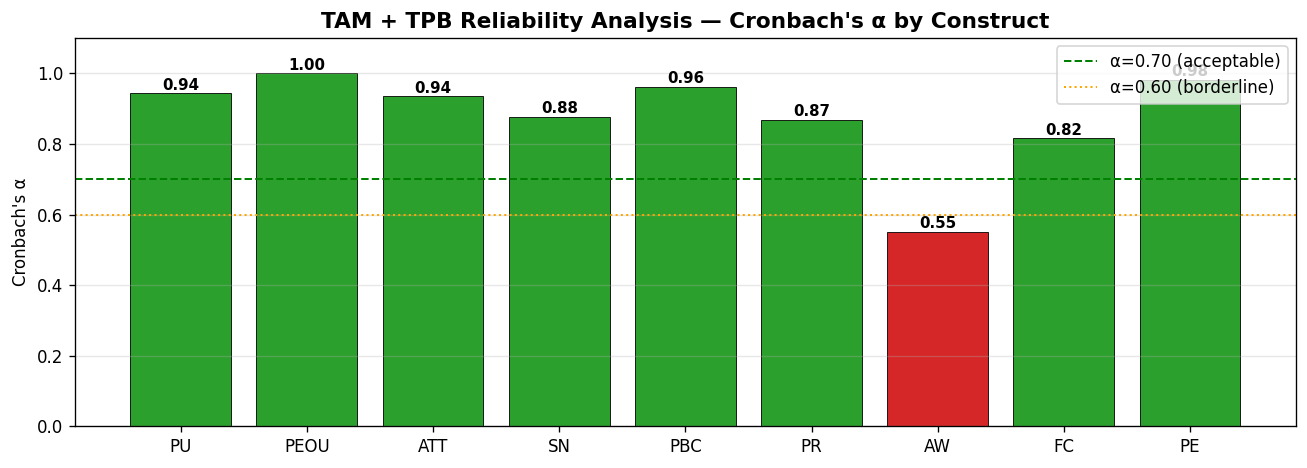

Construct  n_items  alpha
       PU        5  0.944
     PEOU        2  1.000
      ATT        5  0.935
       SN        4  0.877
      PBC        2  0.962
       PR        4  0.868
       AW        3  0.551
       FC        2  0.816
       PE        3  0.982

✅ 1B complete


In [ ]:
alpha_rows = []
for construct, items in CFA_CONSTRUCTS.items():
    present = [i for i in items if i in ind_enc.columns]
    if len(present) < 2:
        alpha_rows.append({'Construct': construct, 'n_items': len(present), 'alpha': np.nan})
        continue
    a = cronbach_alpha(ind_enc, present)
    alpha_rows.append({'Construct': construct, 'n_items': len(present), 'alpha': round(a, 3)})

alpha_df = pd.DataFrame(alpha_rows)
alpha_df.to_csv(OUT_DIR+'cronbach_alpha.csv', index=False)

fig, ax = plt.subplots(figsize=(11, 4))
colors_a = ['#2ca02c' if v >= 0.7 else '#ff7f0e' if v >= 0.6 else '#d62728'
            for v in alpha_df['alpha'].fillna(0)]
bars = ax.bar(alpha_df['Construct'], alpha_df['alpha'].fillna(0),
              color=colors_a, edgecolor='k', linewidth=0.5)
ax.axhline(0.7, color='green', linestyle='--', linewidth=1.2, label='α=0.70 (acceptable)')
ax.axhline(0.6, color='orange', linestyle=':', linewidth=1.2, label='α=0.60 (borderline)')
for bar, val in zip(bars, alpha_df['alpha'].fillna(0)):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.01,
            f'{val:.2f}', ha='center', fontsize=9, fontweight='bold')
ax.set_ylim(0, 1.1)
ax.set_ylabel("Cronbach's α")
ax.set_title("TAM + TPB Reliability Analysis — Cronbach's α by Construct",
             fontsize=13, fontweight='bold')
ax.legend(); ax.grid(axis='y', alpha=0.3)
fig.tight_layout()
fig.savefig(OUT_DIR+'cronbach_alpha.png', dpi=150, bbox_inches='tight')
plt.show()
print(alpha_df.to_string(index=False))
print('\n✅ 1B complete')

### 1C · TLFD curves by purpose & mode (empirical CDF)

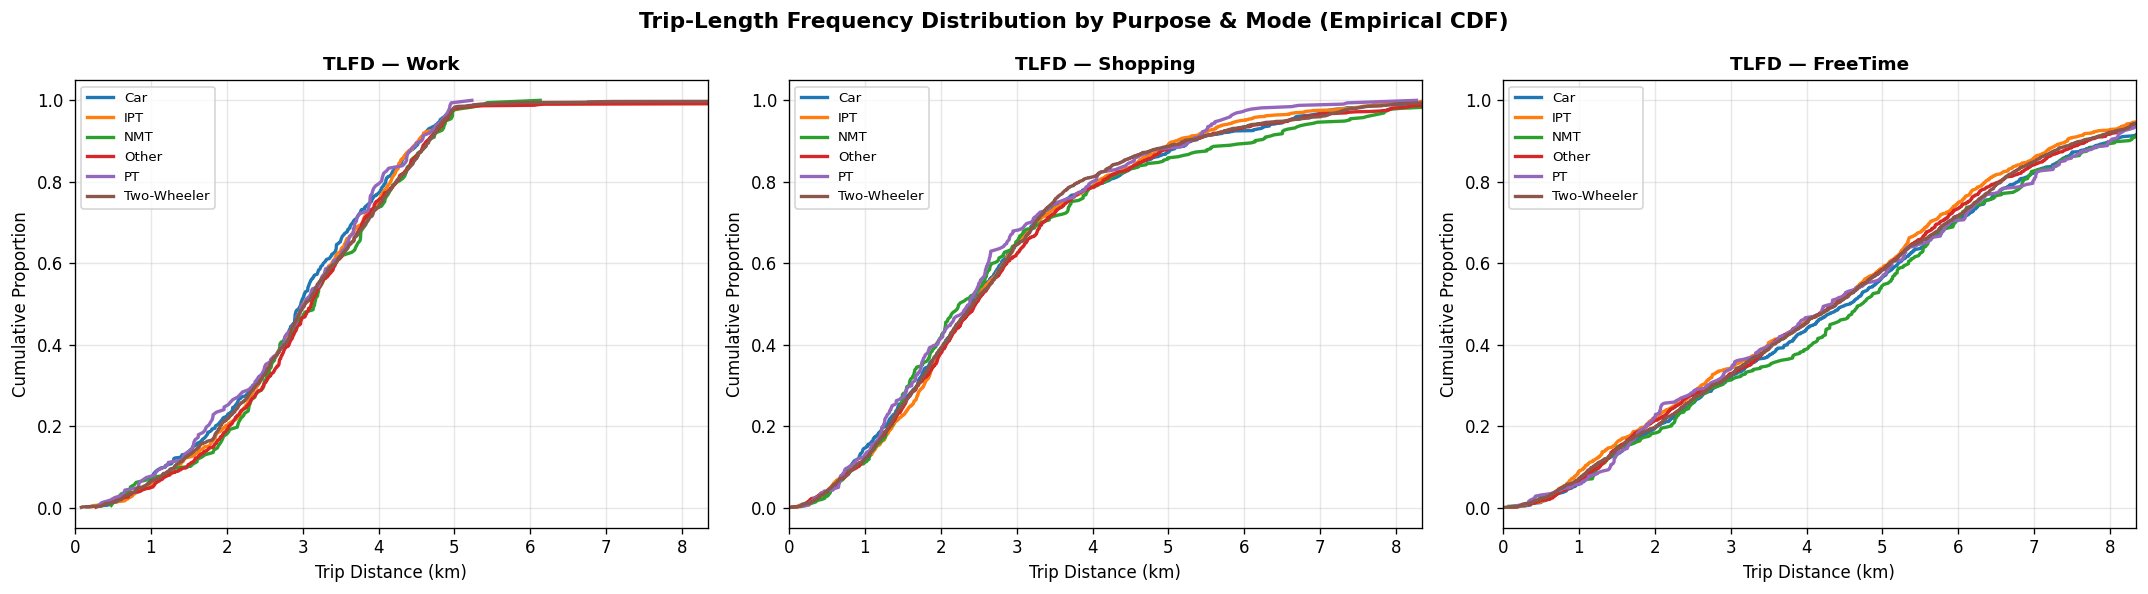

✅ 1C complete


In [ ]:
od = od_raw.copy()
ind_mode = ind_raw[['ResID','Mode_to_Work']].copy()
od_m = od.merge(ind_mode, on='ResID', how='left')

MODE_GROUP = {
    'Car': 'Car', 'Two wheeler': 'Two-Wheeler', 'Two wheeleer': 'Two-Wheeler',
    'Public transport': 'PT', 'Company bus/ Cab': 'PT',
    'Individual Auto': 'IPT', 'Share Auto': 'IPT',
    'Walk': 'NMT', 'Cycle': 'NMT',
}
od_m['Mode_Group'] = od_m['Mode_to_Work'].map(MODE_GROUP).fillna('Other')

purposes = od_m['Purpose'].dropna().unique()
fig, axes = plt.subplots(1, len(purposes), figsize=(6*len(purposes), 5), sharey=False)
if len(purposes) == 1: axes = [axes]

for ax, purp in zip(axes, purposes):
    sub = od_m[od_m['Purpose'] == purp]
    for grp, grp_df in sub.groupby('Mode_Group'):
        vals = grp_df['Distance_km'].dropna()
        if len(vals) < 5: continue
        vals_sorted = np.sort(vals)
        cdf = np.arange(1, len(vals_sorted)+1) / len(vals_sorted)
        ax.plot(vals_sorted, cdf, label=grp, linewidth=2)
    ax.set_xlabel('Trip Distance (km)')
    ax.set_ylabel('Cumulative Proportion')
    ax.set_title(f'TLFD — {purp}', fontsize=11, fontweight='bold')
    ax.legend(fontsize=8); ax.grid(alpha=0.3)
    ax.set_xlim(0, od_m['Distance_km'].quantile(0.97))

fig.suptitle('Trip-Length Frequency Distribution by Purpose & Mode (Empirical CDF)',
             fontsize=13, fontweight='bold')
fig.tight_layout()
fig.savefig(OUT_DIR+'tlfd_curves.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ 1C complete')

### 1D · K-Means BE Archetype clustering
**Improvements:** MinMaxScaler · Distance_to_CBD_km dropped from clustering (r=0.93 multicollinearity) · Silhouette validation · Dynamic archetype labelling by CBD distance · Ghat_Core as regression baseline

Correlation matrix (check for |r| > 0.8):
                       Walkability_Score  Road_Density_Category  \
Walkability_Score                  1.000                  0.221   
Road_Density_Category              0.221                  1.000   
Land_Use_Entropy                   0.020                 -0.005   
Distance_to_CBD_km                -0.929                 -0.315   

                       Land_Use_Entropy  Distance_to_CBD_km  
Walkability_Score                 0.020              -0.929  
Road_Density_Category            -0.005              -0.315  
Land_Use_Entropy                  1.000              -0.017  
Distance_to_CBD_km               -0.017               1.000  


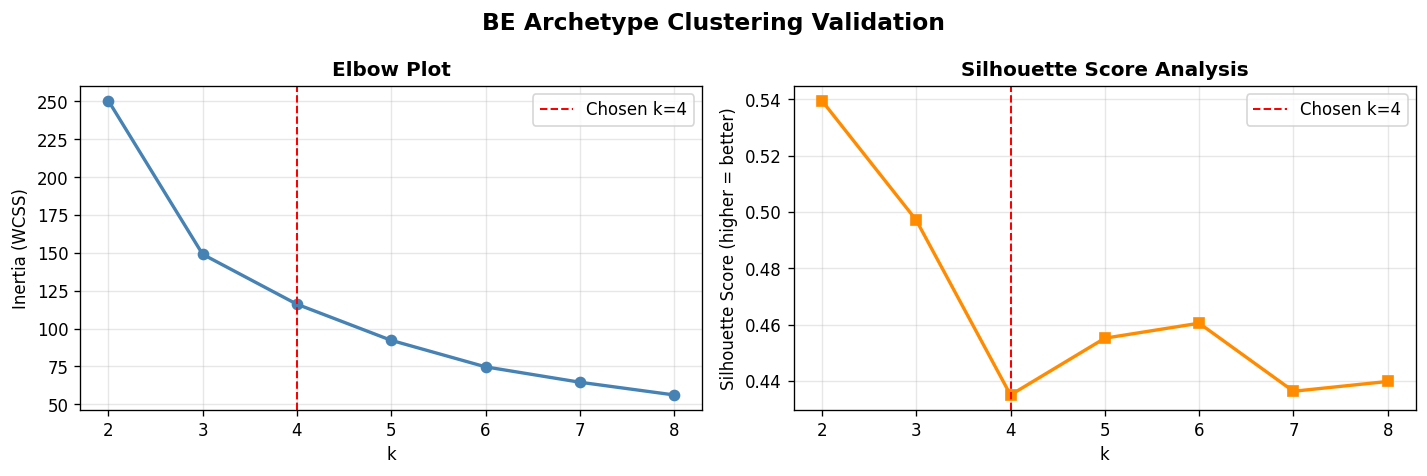

Silhouette scores: {2: np.float64(0.5395), 3: np.float64(0.4971), 4: np.float64(0.4351), 5: np.float64(0.4552), 6: np.float64(0.4605), 7: np.float64(0.4364), 8: np.float64(0.4399)}

Cluster Profiles (k=4):
                      Walkability_Score  Land_Use_Entropy  Distance_to_CBD_km  \
BE_Archetype_Cluster                                                            
0                                 9.447             0.863               2.212   
1                                 9.206             0.667               2.422   
2                                 9.587             0.799               1.416   
3                                 5.023             0.809               5.351   

                      Road_Density_Mean  
BE_Archetype_Cluster                     
0                                 1.000  
1                                 1.002  
2                                 2.225  
3                                 1.000  

Dynamic archetype mapping (sorted by CBD distance):
{2

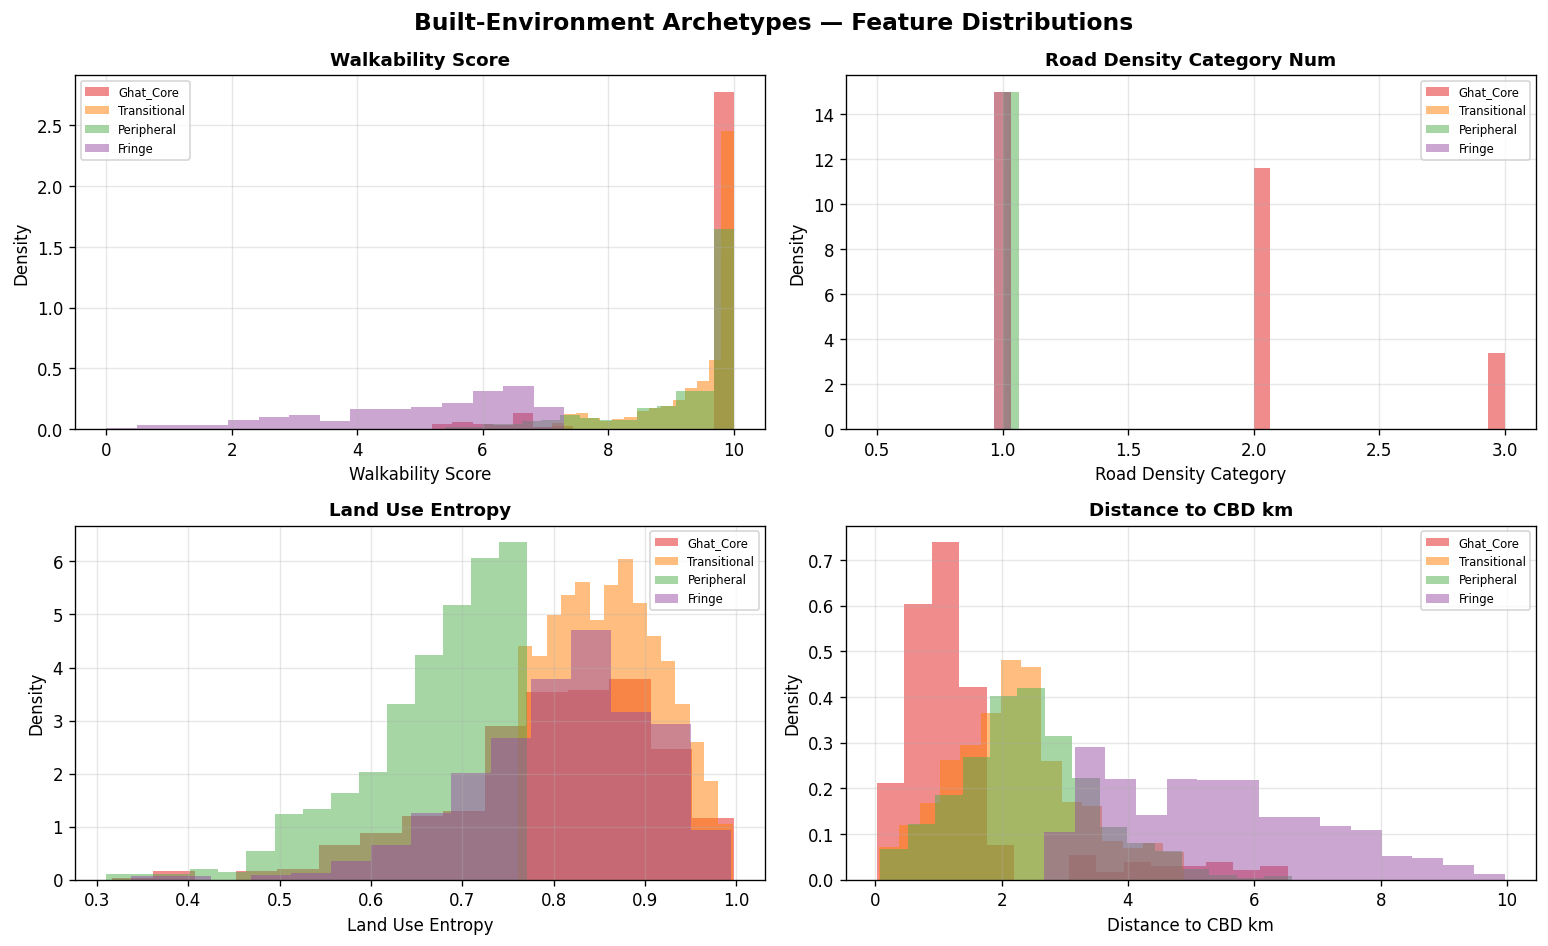


BE dummy columns created (Ghat_Core = baseline):
['BE_Archetype_Cluster', 'BE_Fringe', 'BE_Peripheral', 'BE_Transitional']

Archetype counts:
  Cluster 0 (Transitional): n=1332
  Cluster 1 (Peripheral): n=660
  Cluster 2 (Ghat_Core): n=547
  Cluster 3 (Fringe): n=707

✅ Phase 1 complete — archetypes assigned with dynamic labelling


In [ ]:
from sklearn.preprocessing import MinMaxScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

ind_df = ind_enc.copy()

# ── Data prep ────────────────────────────────────────────────────────────
be_vars = ['Walkability_Score','Road_Density_Category','Land_Use_Entropy','Distance_to_CBD_km']
cluster_data = ind_df[be_vars].copy()
cluster_data.fillna(cluster_data.median(numeric_only=True), inplace=True)

density_mapping = {'Low':1, 'Medium':2, 'High':3}
cluster_data['Road_Density_Category'] = cluster_data['Road_Density_Category'].map(density_mapping).fillna(2)

# ── Multicollinearity check ───────────────────────────────────────────────
corr_check = cluster_data.corr(numeric_only=True)
print('Correlation matrix (check for |r| > 0.8):')
print(corr_check.round(3))

# Drop Distance_to_CBD_km from clustering (r≈-0.93 with Walkability_Score)
# Keep it for profiling and downstream regression
clustering_vars = ['Walkability_Score','Road_Density_Category','Land_Use_Entropy']
cluster_features = cluster_data[clustering_vars]

# MinMaxScaler — bounded features, no outlier distortion
scaler_be = MinMaxScaler()
scaled_features = scaler_be.fit_transform(cluster_features)

# ── Validation: Elbow + Silhouette ────────────────────────────────────────
inertias, sil_scores = [], []
K_RANGE = range(2, 9)
for k in K_RANGE:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(scaled_features)
    inertias.append(km.inertia_)
    sil_scores.append(silhouette_score(scaled_features, labels))

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
ax1.plot(list(K_RANGE), inertias, 'o-', color='steelblue', linewidth=2)
ax1.axvline(4, color='red', linestyle='--', linewidth=1.2, label='Chosen k=4')
ax1.set_xlabel('k'); ax1.set_ylabel('Inertia (WCSS)')
ax1.set_title('Elbow Plot', fontsize=12, fontweight='bold')
ax1.legend(); ax1.grid(alpha=0.3)

ax2.plot(list(K_RANGE), sil_scores, 's-', color='darkorange', linewidth=2)
ax2.axvline(4, color='red', linestyle='--', linewidth=1.2, label='Chosen k=4')
ax2.set_xlabel('k'); ax2.set_ylabel('Silhouette Score (higher = better)')
ax2.set_title('Silhouette Score Analysis', fontsize=12, fontweight='bold')
ax2.legend(); ax2.grid(alpha=0.3)

fig.suptitle('BE Archetype Clustering Validation', fontsize=14, fontweight='bold')
fig.tight_layout()
fig.savefig(OUT_DIR+'kmeans_validation.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'Silhouette scores: { {k: round(s,4) for k,s in zip(K_RANGE, sil_scores)} }')

# ── Final k=4 fit ─────────────────────────────────────────────────────────
km4 = KMeans(n_clusters=4, random_state=42, n_init=20)
ind_df['BE_Archetype_Cluster'] = km4.fit_predict(scaled_features)

# ── Cluster profiles ──────────────────────────────────────────────────────
cluster_summary = ind_df.groupby('BE_Archetype_Cluster')[
    ['Walkability_Score','Land_Use_Entropy','Distance_to_CBD_km']
].mean()
cluster_summary['Road_Density_Mean'] = cluster_features.groupby(
    ind_df['BE_Archetype_Cluster'])['Road_Density_Category'].mean()
print('\nCluster Profiles (k=4):')
print(cluster_summary.round(3))

# ── Dynamic labelling by Distance_to_CBD_km ───────────────────────────────
sorted_clusters = cluster_summary.sort_values('Distance_to_CBD_km').index.tolist()
dynamic_mapping = {
    sorted_clusters[0]: 'Ghat_Core',
    sorted_clusters[1]: 'Transitional',
    sorted_clusters[2]: 'Peripheral',
    sorted_clusters[3]: 'Fringe',
}
print('\nDynamic archetype mapping (sorted by CBD distance):')
print(dynamic_mapping)
ind_df['BE_Archetype_Name'] = ind_df['BE_Archetype_Cluster'].map(dynamic_mapping)

# ── Archetype profile plot ────────────────────────────────────────────────
plot_feats = ['Walkability_Score','Road_Density_Category','Land_Use_Entropy','Distance_to_CBD_km']
ind_df['Road_Density_Category_Num'] = cluster_data['Road_Density_Category']
plot_feats_real = ['Walkability_Score','Road_Density_Category_Num','Land_Use_Entropy','Distance_to_CBD_km']
arch_palette = {'Ghat_Core':'#e41a1c','Transitional':'#ff7f00','Peripheral':'#4daf4a','Fringe':'#984ea3'}

fig, axes = plt.subplots(2, 2, figsize=(13, 8))
axes = axes.flatten()
for i, feat in enumerate(plot_feats_real):
    ax = axes[i]
    for arch, color in arch_palette.items():
        vals = ind_df[ind_df['BE_Archetype_Name']==arch][feat].dropna()
        if len(vals) > 0:
            ax.hist(vals, bins=15, alpha=0.5, label=arch, density=True, color=color)
    ax.set_xlabel(feat.replace('_',' ').replace('Category Num','Category'))
    ax.set_ylabel('Density'); ax.set_title(feat.replace('_',' '), fontsize=11, fontweight='bold')
    ax.legend(fontsize=7); ax.grid(alpha=0.3)
fig.suptitle('Built-Environment Archetypes — Feature Distributions', fontsize=14, fontweight='bold')
fig.tight_layout()
fig.savefig(OUT_DIR+'be_archetype_profiles.png', dpi=150, bbox_inches='tight')
plt.show()
ind_df.drop('Road_Density_Category_Num', axis=1, inplace=True, errors='ignore')

# ── Dummy variables (Ghat_Core = regression baseline) ────────────────────
cols_to_drop = [c for c in ind_df.columns
                if c.startswith('BE_') and c not in ['BE_Archetype_Cluster','BE_Archetype_Name']]
ind_df.drop(columns=cols_to_drop, inplace=True, errors='ignore')
ind_df = pd.get_dummies(ind_df, columns=['BE_Archetype_Name'], prefix='BE')
ind_df.drop('BE_Ghat_Core', axis=1, inplace=True, errors='ignore')
for c in [col for col in ind_df.columns if col.startswith('BE_') and
          col not in ['BE_Archetype_Cluster']]:
    ind_df[c] = ind_df[c].astype(int)

ind_df.to_csv(OUT_DIR+'ind_with_BE_archetype.csv', index=False)
print('\nBE dummy columns created (Ghat_Core = baseline):')
print([c for c in ind_df.columns if c.startswith('BE_')])
print('\nArchetype counts:')
for arch, count in ind_df.groupby('BE_Archetype_Cluster').size().items():
    label = dynamic_mapping.get(arch, '?')
    print(f'  Cluster {arch} ({label}): n={count}')
print('\n✅ Phase 1 complete — archetypes assigned with dynamic labelling')

---
# 🗺️ PHASE 2 — Spatial Analysis
**Tasks:** H3 hexbin · Desire-line maps · Top-20 OD corridors · PT coverage gap · Interactive map with all corridors overlaid on bus network

**Key additions:** Corridor_Demand_Volume for Phase 3 · All 20 corridors overlaid on Folium map with gap-index colouring

### 2A · H3 hexagonal binning & Corridor_Demand_Volume

H3 hex grid: 122 cells | Total non-intra trips: 15,821


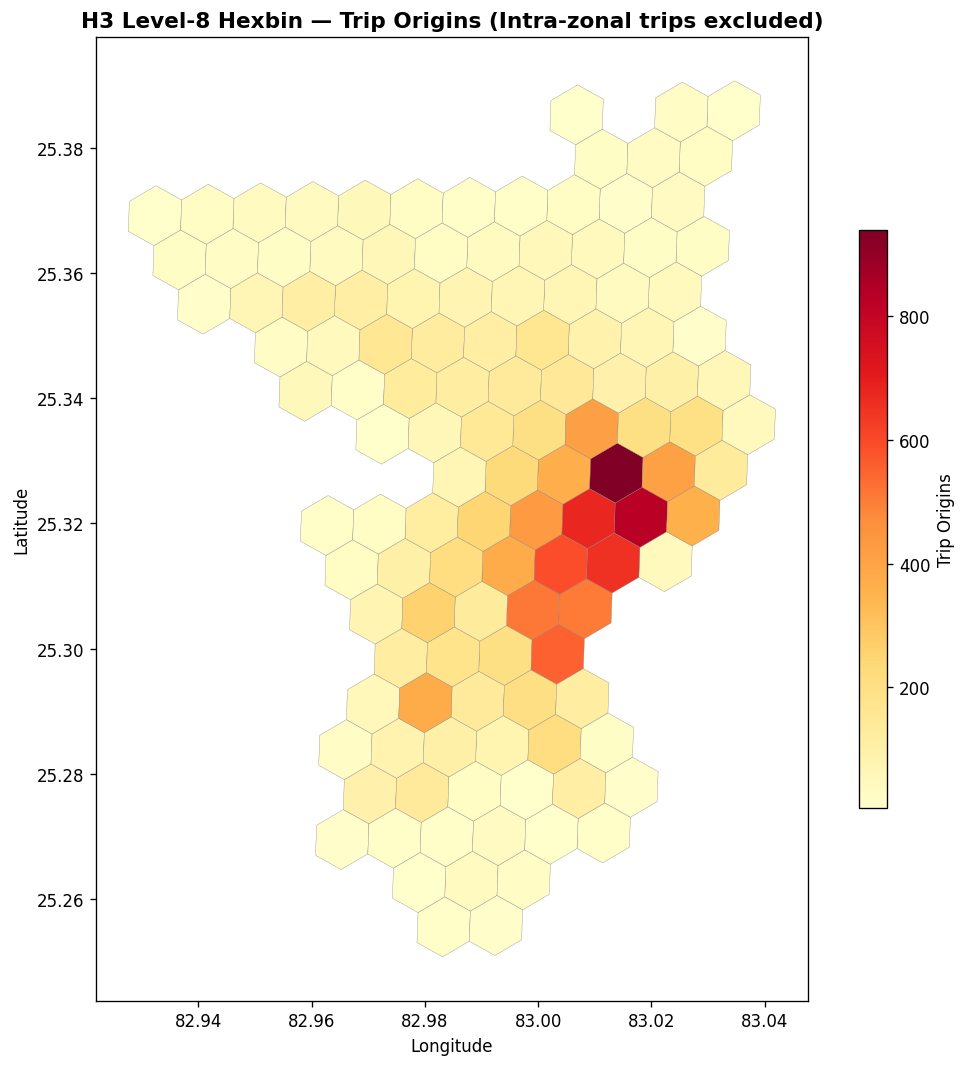

✅ 2A complete


In [ ]:
import h3
import geopandas as gpd
from shapely.geometry import LineString, Point, Polygon

od = od_raw.copy()
od = od.dropna(subset=['Origin_Lat','Origin_Lng','Dest_Lat','Dest_Lng'])

def latlon_to_h3(lat, lon, res=8):
    try: return h3.latlng_to_cell(lat, lon, res)
    except:
        try: return h3.geo_to_h3(lat, lon, res)  # v3 fallback
        except: return None

def h3_to_centroid(cell):
    try: return h3.cell_to_latlng(cell)
    except:
        try: return h3.h3_to_geo(cell)
        except: return (None, None)

od['Origin_H3'] = od.apply(lambda r: latlon_to_h3(r['Origin_Lat'], r['Origin_Lng'], 8), axis=1)
od['Dest_H3']   = od.apply(lambda r: latlon_to_h3(r['Dest_Lat'],   r['Dest_Lng'],   8), axis=1)

# Filter intra-zonal trips BEFORE aggregating (memory efficient)
od = od[od['Origin_H3'] != od['Dest_H3']].dropna(subset=['Origin_H3','Dest_H3'])

# ── Corridor_Demand_Volume (bridges Phase 2 → Phase 3) ───────────────────
flow_all = od.groupby(['Origin_H3','Dest_H3']).size().reset_index(name='Corridor_Demand_Volume')
od = od.merge(flow_all, on=['Origin_H3','Dest_H3'], how='left')

# Trip counts per hex cell (origin-side)
origin_counts = od.groupby('Origin_H3')['ResID'].count().reset_index()
origin_counts.columns = ['H3_Cell','Trip_Origins']
origin_counts.to_csv(OUT_DIR+'h3_origin_counts.csv', index=False)

# Convert H3 cells to polygons
hex_polys = []
for cell, cnt in zip(origin_counts['H3_Cell'], origin_counts['Trip_Origins']):
    try:
        boundary = h3.cell_to_boundary(cell)
        latlons = [(lon, lat) for lat, lon in boundary]
        hex_polys.append({'H3_Cell': cell, 'Trip_Origins': cnt, 'geometry': Polygon(latlons)})
    except: pass

hex_gdf = gpd.GeoDataFrame(hex_polys, crs='EPSG:4326')
hex_gdf.to_file(OUT_DIR+'h3_origins.geojson', driver='GeoJSON')
print(f'H3 hex grid: {len(hex_gdf)} cells | Total non-intra trips: {origin_counts["Trip_Origins"].sum():,}')

fig, ax = plt.subplots(figsize=(9, 9))
hex_gdf.plot(column='Trip_Origins', cmap='YlOrRd', ax=ax,
             legend=True, legend_kwds={'label':'Trip Origins','shrink':0.6},
             edgecolor='gray', linewidth=0.2)
ax.set_title('H3 Level-8 Hexbin — Trip Origins (Intra-zonal trips excluded)',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Longitude'); ax.set_ylabel('Latitude')
fig.tight_layout()
fig.savefig(OUT_DIR+'h3_hexbin_origins.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ 2A complete')

### 2B · Top-20 OD corridor pairs by trip purpose

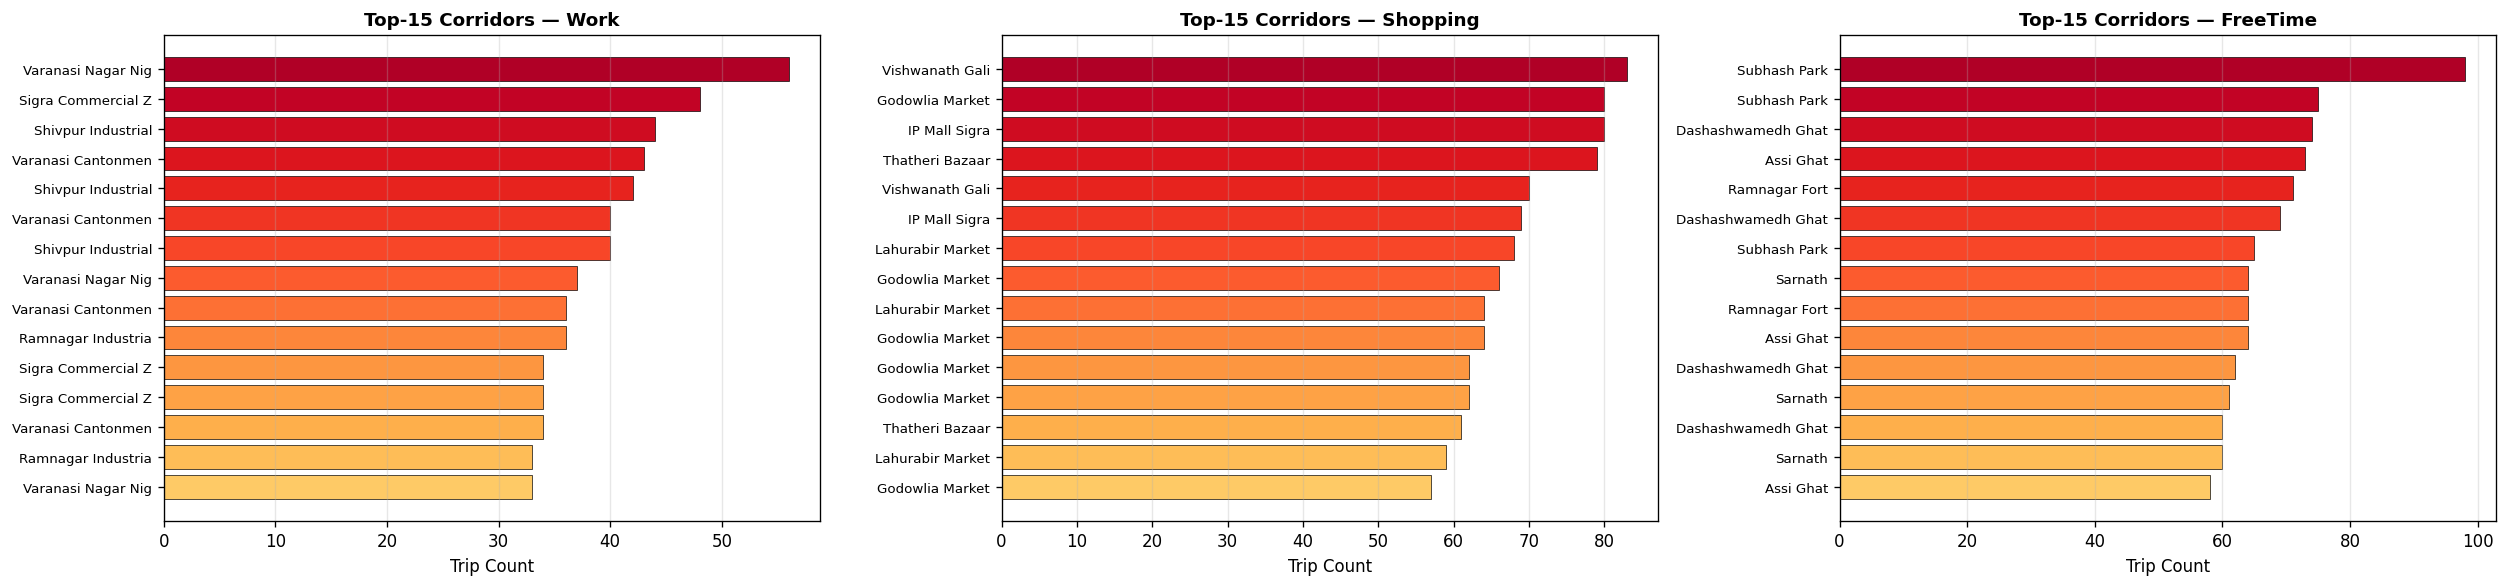

 Purpose                 Dest_Name  Trip_Count  Avg_Distance_km
    Work      Varanasi Nagar Nigam          56         2.991118
    Work     Sigra Commercial Zone          48         3.281031
    Work Shivpur Industrial Estate          44         3.608664
    Work       Varanasi Cantonment          43         2.216267
    Work Shivpur Industrial Estate          42         4.453993
    Work       Varanasi Cantonment          40         2.922429
    Work Shivpur Industrial Estate          40         4.295730
    Work      Varanasi Nagar Nigam          37         2.748060
    Work       Varanasi Cantonment          36         3.135255
    Work  Ramnagar Industrial Area          36         4.106168
    Work     Sigra Commercial Zone          34         1.551644
    Work     Sigra Commercial Zone          34         2.865986
    Work       Varanasi Cantonment          34         2.414020
    Work  Ramnagar Industrial Area          33         3.942732
    Work      Varanasi Nagar Nigam      

In [ ]:
purposes = od['Purpose'].dropna().unique()
top_corridors = {}

for purp in purposes:
    sub = od[od['Purpose'] == purp].copy()
    corr = (sub.groupby(['Origin_H3','Dest_H3','Dest_Name'])
               .agg(Trip_Count=('ResID','count'),
                    Avg_Distance_km=('Distance_km','mean'),
                    Avg_Time_Min=('Travel_Time_Min','mean'),
                    Corridor_Demand_Volume=('Corridor_Demand_Volume','mean'))
               .reset_index()
               .sort_values('Trip_Count', ascending=False)
               .head(20))
    # Add H3 centroids for map drawing
    corr['O_Lat'], corr['O_Lng'] = zip(*corr['Origin_H3'].apply(h3_to_centroid))
    corr['D_Lat'], corr['D_Lng'] = zip(*corr['Dest_H3'].apply(h3_to_centroid))
    corr['Purpose'] = purp
    top_corridors[purp] = corr

top_all = pd.concat(top_corridors.values(), ignore_index=True)
top_all.to_csv(OUT_DIR+'top20_od_corridors.csv', index=False)

fig, axes = plt.subplots(1, len(purposes), figsize=(7*len(purposes), 5))
if len(purposes)==1: axes=[axes]
for ax, purp in zip(axes, purposes):
    df_p = top_corridors[purp].head(15)
    labels = df_p['Dest_Name'].str[:18]
    colors_bar = plt.cm.YlOrRd(np.linspace(0.3, 0.9, len(df_p)))[::-1]
    ax.barh(range(len(df_p)), df_p['Trip_Count'], color=colors_bar, edgecolor='k', linewidth=0.4)
    ax.set_yticks(range(len(df_p))); ax.set_yticklabels(labels, fontsize=8)
    ax.invert_yaxis()
    ax.set_xlabel('Trip Count')
    ax.set_title(f'Top-15 Corridors — {purp}', fontsize=11, fontweight='bold')
    ax.grid(axis='x', alpha=0.3)
fig.tight_layout()
fig.savefig(OUT_DIR+'top20_corridors_chart.png', dpi=150, bbox_inches='tight')
plt.show()
print(top_all[['Purpose','Dest_Name','Trip_Count','Avg_Distance_km']].to_string(index=False))
print('\n✅ 2B complete')

### 2C · Desire-line maps by purpose

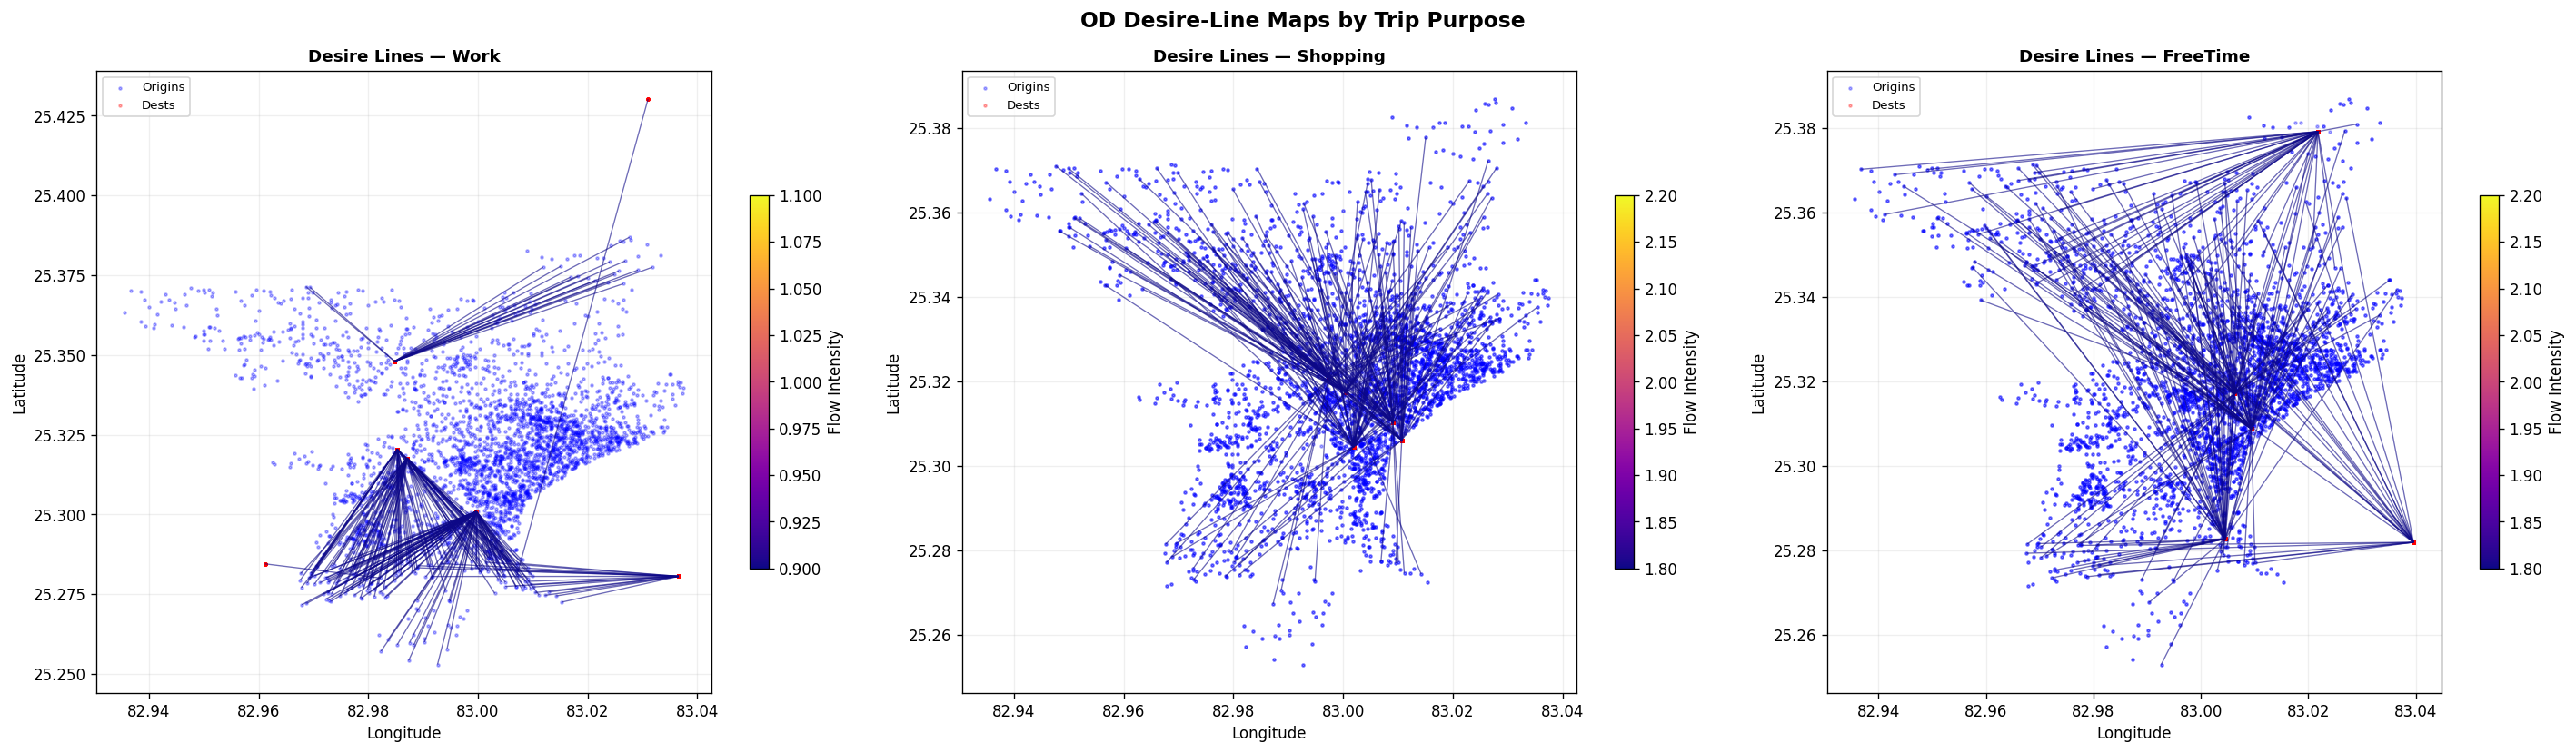

✅ 2C complete


In [ ]:
from matplotlib.collections import LineCollection
from matplotlib.colors import Normalize

purposes_list = list(purposes)
fig, axes = plt.subplots(1, len(purposes_list), figsize=(8*len(purposes_list), 7))
if len(purposes_list)==1: axes=[axes]

for ax, purp in zip(axes, purposes_list):
    sub = od[od['Purpose']==purp].dropna(subset=['Origin_Lat','Origin_Lng','Dest_Lat','Dest_Lng'])
    od_pairs = (sub.groupby(['Origin_Lat','Origin_Lng','Dest_Lat','Dest_Lng'])
                   .size().reset_index(name='Count')
                   .sort_values('Count', ascending=False).head(200))
    norm = Normalize(vmin=od_pairs['Count'].min(), vmax=od_pairs['Count'].max())
    cmap = plt.cm.plasma
    lines, colors_lc = [], []
    for _, row in od_pairs.iterrows():
        lines.append([(row['Origin_Lng'],row['Origin_Lat']),(row['Dest_Lng'],row['Dest_Lat'])])
        colors_lc.append(cmap(norm(row['Count'])))
    lc = LineCollection(lines, colors=colors_lc, linewidths=0.8, alpha=0.6)
    ax.add_collection(lc)
    ax.scatter(sub['Origin_Lng'], sub['Origin_Lat'], s=3, c='blue', alpha=0.3, label='Origins')
    ax.scatter(sub['Dest_Lng'],   sub['Dest_Lat'],   s=3, c='red',  alpha=0.3, label='Dests')
    ax.autoscale()
    ax.set_title(f'Desire Lines — {purp}', fontsize=11, fontweight='bold')
    ax.set_xlabel('Longitude'); ax.set_ylabel('Latitude')
    ax.legend(fontsize=8); ax.grid(alpha=0.2)
    sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
    sm.set_array([])
    plt.colorbar(sm, ax=ax, label='Flow Intensity', shrink=0.6)
fig.suptitle('OD Desire-Line Maps by Trip Purpose', fontsize=14, fontweight='bold')
fig.tight_layout()
fig.savefig(OUT_DIR+'desire_line_maps.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ 2C complete')

### 2D · Load UPSRTC bus routes & 500m walk buffer

In [ ]:
from shapely.ops import unary_union

bus_gdf = gpd.read_file(GEOJSON_PATH, on_invalid='warn')
bus_gdf = bus_gdf[bus_gdf.geometry.notnull()]
bus_gdf = bus_gdf[~bus_gdf.geometry.is_empty]
# Remove degenerate 1-point LineStrings
bus_gdf = bus_gdf[bus_gdf.geometry.apply(
    lambda g: hasattr(g, 'coords') and len(list(g.coords)) >= 2)]
bus_gdf = bus_gdf.set_crs('EPSG:4326', allow_override=True)
print(f'UPSRTC bus routes: {len(bus_gdf)} valid segments')
print(f'Unique route names: {bus_gdf["name"].nunique()}')
print(f'Total network length: {bus_gdf["distance_m"].sum()/1000:.1f} km')

bus_utm = bus_gdf.to_crs('EPSG:32644')
bus_utm['geometry'] = bus_utm.geometry.make_valid()
WALK_BUFFER_M = 500
bus_buffer_union = unary_union(bus_utm[~bus_utm.geometry.is_empty].geometry.buffer(WALK_BUFFER_M))
bus_buffer_gdf = gpd.GeoDataFrame(geometry=[bus_buffer_union],
                                   crs='EPSG:32644').to_crs('EPSG:4326')
bus_buffer_gdf.to_file(OUT_DIR+'bus_walking_buffer.geojson', driver='GeoJSON')
print(f'500m walk buffer created. ✅ 2D complete')

UPSRTC bus routes: 449 valid segments
Unique route names: 38
Total network length: 426.6 km
500m walk buffer created. ✅ 2D complete


### 2E · Per-corridor PT coverage gap index

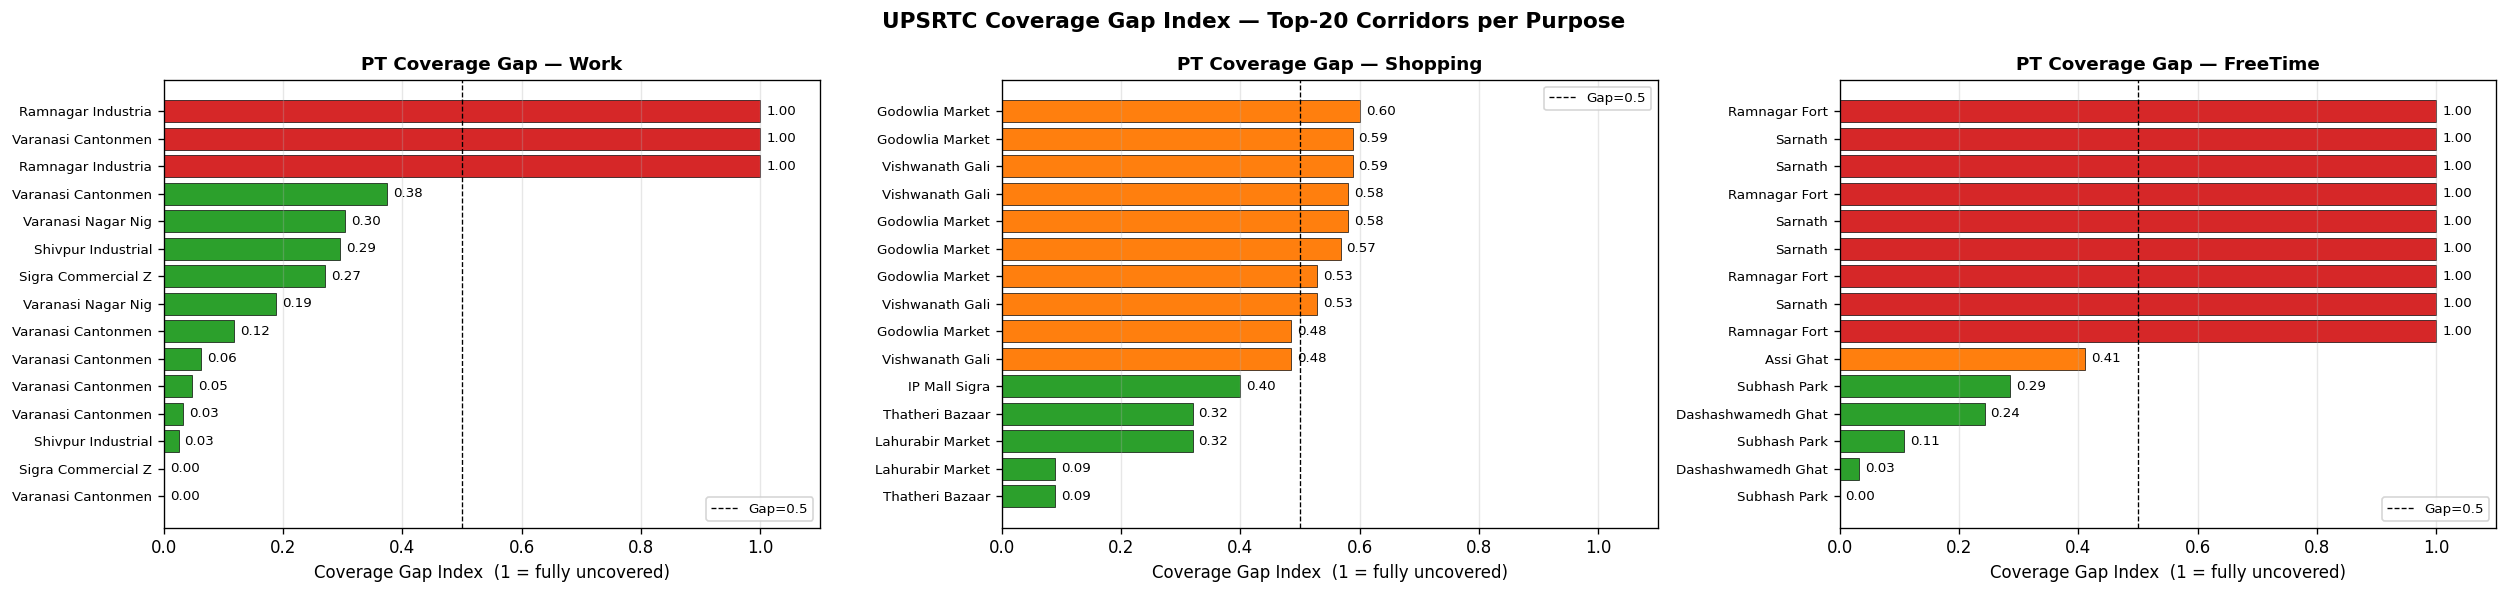


Top uncovered corridors (Gap > 0.7):
 Purpose                Dest_Name  Trip_Count  Gap_Index
    Work Ramnagar Industrial Area          36        1.0
    Work Ramnagar Industrial Area          33        1.0
    Work      Varanasi Cantonment          31        1.0
FreeTime            Ramnagar Fort          71        1.0
FreeTime                  Sarnath          64        1.0
FreeTime            Ramnagar Fort          64        1.0
FreeTime                  Sarnath          61        1.0
FreeTime                  Sarnath          60        1.0
FreeTime            Ramnagar Fort          57        1.0
FreeTime            Ramnagar Fort          56        1.0
FreeTime                  Sarnath          55        1.0
FreeTime                  Sarnath          55        1.0

✅ 2E complete


In [ ]:
gap_rows = []
buf_union = bus_buffer_gdf.geometry.iloc[0]

for purp in purposes:
    top20 = top_corridors[purp]
    od_purp = od[od['Purpose']==purp].copy()

    for _, corr_row in top20.iterrows():
        o_h3   = corr_row['Origin_H3']
        d_h3   = corr_row['Dest_H3']
        d_name = corr_row['Dest_Name']
        trips_here = od_purp[(od_purp['Origin_H3']==o_h3) & (od_purp['Dest_H3']==d_h3)]
        if len(trips_here)==0: continue

        origin_pts = [Point(r['Origin_Lng'], r['Origin_Lat'])
                      for _, r in trips_here.dropna(subset=['Origin_Lat','Origin_Lng']).iterrows()]
        dest_pts   = [Point(r['Dest_Lng'],   r['Dest_Lat'])
                      for _, r in trips_here.dropna(subset=['Dest_Lat','Dest_Lng']).iterrows()]

        origin_cov_rate = (sum(1 for p in origin_pts if buf_union.contains(p))
                           / len(origin_pts)) if origin_pts else 0
        dest_cov_rate   = (sum(1 for p in dest_pts   if buf_union.contains(p))
                           / len(dest_pts))   if dest_pts   else 0
        gap_index = 1 - (origin_cov_rate * dest_cov_rate)

        gap_rows.append({
            'Purpose': purp,
            'Origin_H3': o_h3, 'Dest_H3': d_h3, 'Dest_Name': d_name,
            'Trip_Count': int(corr_row['Trip_Count']),
            'O_Lat': corr_row['O_Lat'], 'O_Lng': corr_row['O_Lng'],
            'D_Lat': corr_row['D_Lat'], 'D_Lng': corr_row['D_Lng'],
            'Origin_Coverage_Rate': round(origin_cov_rate, 3),
            'Dest_Coverage_Rate':   round(dest_cov_rate,   3),
            'Gap_Index':            round(gap_index,        3),
        })

gap_df = pd.DataFrame(gap_rows)
gap_df.to_csv(OUT_DIR+'pt_coverage_gap.csv', index=False)

# ── Gap index bar chart ───────────────────────────────────────────────────
fig, axes = plt.subplots(1, len(purposes), figsize=(7*len(purposes), 5))
if len(purposes)==1: axes=[axes]
for ax, purp in zip(axes, purposes):
    sub_gap = gap_df[gap_df['Purpose']==purp].sort_values('Gap_Index', ascending=False).head(15)
    labels = sub_gap['Dest_Name'].str[:18]
    bar_colors = ['#d62728' if g>0.7 else '#ff7f0e' if g>0.4 else '#2ca02c'
                  for g in sub_gap['Gap_Index']]
    bars = ax.barh(range(len(sub_gap)), sub_gap['Gap_Index'],
                   color=bar_colors, edgecolor='k', linewidth=0.4)
    ax.set_yticks(range(len(sub_gap))); ax.set_yticklabels(labels, fontsize=8)
    ax.invert_yaxis()
    ax.axvline(0.5, color='black', linestyle='--', linewidth=0.8, label='Gap=0.5')
    ax.set_xlim(0, 1.1)
    ax.set_xlabel('Coverage Gap Index  (1 = fully uncovered)')
    ax.set_title(f'PT Coverage Gap — {purp}', fontsize=11, fontweight='bold')
    ax.grid(axis='x', alpha=0.3); ax.legend(fontsize=8)
    for bar, val in zip(bars, sub_gap['Gap_Index']):
        ax.text(bar.get_width()+0.01, bar.get_y()+bar.get_height()/2,
                f'{val:.2f}', va='center', fontsize=8)
fig.suptitle('UPSRTC Coverage Gap Index — Top-20 Corridors per Purpose',
             fontsize=13, fontweight='bold')
fig.tight_layout()
fig.savefig(OUT_DIR+'pt_coverage_gap_chart.png', dpi=150, bbox_inches='tight')
plt.show()
print('\nTop uncovered corridors (Gap > 0.7):')
print(gap_df[gap_df['Gap_Index']>0.7]
      .sort_values('Gap_Index',ascending=False)
      [['Purpose','Dest_Name','Trip_Count','Gap_Index']].head(15).to_string(index=False))
print('\n✅ 2E complete')

### 2F · Interactive Folium map — ALL top-20 corridors overlaid on bus network
**New:** All top-20 corridors per purpose plotted with gap-index colour coding (🔴 high gap, 🟠 medium, 🟢 covered). Bus routes, 500m buffer, BE archetypes, and OD heatmap included.

In [ ]:
import folium
from folium.plugins import HeatMap
import colorsys

def gap_to_color(gap):
    """Map gap index to red (1.0) → green (0.0) via orange."""
    if gap > 0.7:   return '#d62728'  # red — high gap
    elif gap > 0.4: return '#ff7f0e'  # orange — medium gap
    else:           return '#2ca02c'  # green — well covered

# ── Base map ──────────────────────────────────────────────────────────────
m = folium.Map(location=[25.317, 82.973], zoom_start=12,
               tiles='CartoDB positron')

# ── Layer 1: UPSRTC bus routes ────────────────────────────────────────────
bus_fg = folium.FeatureGroup(name='🚌 UPSRTC Bus Routes', show=True)
for _, row in bus_gdf.iterrows():
    try:
        coords = [(lat, lon) for lon, lat in row.geometry.coords]
        name   = str(row.get('name','Route segment')) if row.get('name') else 'Route segment'
        folium.PolyLine(coords, color='#1f78b4', weight=2.5, opacity=0.8,
                        tooltip=f"🚌 {name} | {row['distance_m']:.0f} m").add_to(bus_fg)
    except: pass
bus_fg.add_to(m)

# ── Layer 2: 500m walk-catchment buffer ───────────────────────────────────
buf_fg = folium.FeatureGroup(name='🔵 500m Walk Buffer', show=False)
folium.GeoJson(bus_buffer_gdf.__geo_interface__,
               style_function=lambda x: {'fillColor':'#1f78b4','color':'#1f78b4',
                                         'weight':0.5,'fillOpacity':0.10}).add_to(buf_fg)
buf_fg.add_to(m)

# ── Layer 3: ALL top-20 corridors per purpose, colour-coded by gap ────────
# Create a separate feature group per purpose
for purp in purposes:
    purp_gaps = gap_df[gap_df['Purpose']==purp].copy()
    corr_fg = folium.FeatureGroup(name=f'📍 Corridors — {purp}', show=(purp=='Work'))
    for _, row in purp_gaps.iterrows():
        if pd.isna(row['O_Lat']) or pd.isna(row['D_Lat']): continue
        color    = gap_to_color(row['Gap_Index'])
        weight   = max(1.5, min(6, row['Trip_Count'] / 3))  # thickness ∝ volume
        dash     = '5 4' if row['Gap_Index'] > 0.5 else None
        gap_icon = '🔴' if row['Gap_Index']>0.7 else '🟠' if row['Gap_Index']>0.4 else '🟢'
        tooltip  = (f"{gap_icon} {row['Dest_Name']} | Gap: {row['Gap_Index']:.2f} | "
                    f"Trips: {row['Trip_Count']} | "
                    f"O-cov: {row['Origin_Coverage_Rate']:.0%} | D-cov: {row['Dest_Coverage_Rate']:.0%}")
        folium.PolyLine(
            [(row['O_Lat'], row['O_Lng']), (row['D_Lat'], row['D_Lng'])],
            color=color, weight=weight, opacity=0.85,
            dash_array=dash, tooltip=tooltip
        ).add_to(corr_fg)
        # Origin marker
        folium.CircleMarker(
            location=[row['O_Lat'], row['O_Lng']], radius=5,
            color=color, fill=True, fill_color=color, fill_opacity=0.9,
            tooltip=f"Origin hex | {purp}"
        ).add_to(corr_fg)
        # Destination marker
        folium.CircleMarker(
            location=[row['D_Lat'], row['D_Lng']], radius=5,
            color=color, fill=True, fill_color='white', fill_opacity=0.9,
            tooltip=f"Dest: {row['Dest_Name']}"
        ).add_to(corr_fg)
    corr_fg.add_to(m)

# ── Layer 4: Survey respondents by BE archetype ───────────────────────────
ind_arch2 = pd.read_csv(OUT_DIR+'ind_with_BE_archetype.csv')
arch_colors_map = {'Ghat_Core':'#e41a1c','Transitional':'#ff7f00',
                   'Peripheral':'#4daf4a','Fringe':'#984ea3'}
resp_fg = folium.FeatureGroup(name='👤 Survey Respondents (BE Archetype)', show=False)
for _, row in ind_arch2.dropna(subset=['Latitude_WGS84','Longitude_WGS84']).iterrows():
    arch = row.get('BE_Archetype_Name', '?')
    color = arch_colors_map.get(arch, '#999999')
    folium.CircleMarker(
        location=[row['Latitude_WGS84'], row['Longitude_WGS84']],
        radius=4, color=color, fill=True, fill_color=color, fill_opacity=0.7,
        tooltip=f"ResID {int(row['ResID'])} | {arch} | {row.get('Mode_to_Work','?')}"
    ).add_to(resp_fg)
resp_fg.add_to(m)

# ── Layer 5: OD origin heatmap ────────────────────────────────────────────
heat_data = od_raw.dropna(subset=['Origin_Lat','Origin_Lng'])[['Origin_Lat','Origin_Lng']].values.tolist()
HeatMap(heat_data, name='🔥 OD Origin Heatmap', radius=12, blur=15, min_opacity=0.3).add_to(m)

# ── Legend ────────────────────────────────────────────────────────────────
legend_html = """
<div style='position:fixed;bottom:30px;left:30px;z-index:1000;background:white;
            padding:14px 18px;border-radius:10px;border:1px solid #ccc;
            font-size:12px;font-family:sans-serif;box-shadow:2px 2px 6px rgba(0,0,0,0.15);'>
<b style='font-size:13px'>🏙️ Hitkavyam — Varanasi</b><br>
<b>Transit Infrastructure</b><br>
<span style='color:#1f78b4'>━━</span> UPSRTC Bus Routes<br>
<span style='color:#1f78b4;opacity:0.4'>▓▓</span> 500m Walk Catchment<br><br>
<b>Corridor Coverage (Desire Lines)</b><br>
<span style='color:#d62728'>━━</span> High Gap (>0.7) — Underserved<br>
<span style='color:#ff7f0e'>━━</span> Medium Gap (0.4–0.7)<br>
<span style='color:#2ca02c'>━━</span> Low Gap (<0.4) — Well Covered<br>
<i style='font-size:10px'>Line thickness ∝ trip volume</i><br><br>
<b>BE Archetypes</b><br>
<span style='color:#e41a1c'>●</span> Ghat-Core &nbsp;&nbsp;
<span style='color:#ff7f00'>●</span> Transitional<br>
<span style='color:#4daf4a'>●</span> Peripheral &nbsp;
<span style='color:#984ea3'>●</span> Fringe
</div>"""
m.get_root().html.add_child(folium.Element(legend_html))

folium.LayerControl(collapsed=False).add_to(m)
map_path = OUT_DIR+'hitkavyam_interactive_map.html'
m.save(map_path)
print(f'✅ Interactive map saved → {map_path}')
print('Layers included:')
print('  🚌 UPSRTC Bus Routes')
print('  🔵 500m Walk Buffer')
for purp in purposes:
    n_red = len(gap_df[(gap_df['Purpose']==purp)&(gap_df['Gap_Index']>0.7)])
    print(f'  📍 Top-20 Corridors — {purp} ({n_red} high-gap corridors in red)')
print('  👤 Survey Respondents (BE Archetype)')
print('  🔥 OD Origin Heatmap')
print('\n✅ Phase 2 complete')

✅ Interactive map saved → outputs/hitkavyam_interactive_map.html
Layers included:
  🚌 UPSRTC Bus Routes
  🔵 500m Walk Buffer
  📍 Top-20 Corridors — Work (3 high-gap corridors in red)
  📍 Top-20 Corridors — Shopping (0 high-gap corridors in red)
  📍 Top-20 Corridors — FreeTime (9 high-gap corridors in red)
  👤 Survey Respondents (BE Archetype)
  🔥 OD Origin Heatmap

✅ Phase 2 complete


---
# 🧠 PHASE 3 — Behavioural Modelling
**Tasks:** True CFA (factor_analyzer) → Corridor-integrated MNLogit → Ordinal logit shift willingness with subgroups

**Key improvements vs previous version:**
- ✅ `factor_analyzer` ConfirmatoryFactorAnalyzer — tests pre-specified TAM+TPB structure (not sklearn EFA)
- ✅ True factor scores via `cfa.transform()` — not simple item means
- ✅ Corridor_Demand_Volume from Phase 2 as impedance predictor
- ✅ Income as dummy variables (Cat1 = baseline) — non-linear income effects
- ✅ Car explicitly forced to MNL baseline (category 0)
- ✅ Ordinal logit: variance checks · Ghat-Core drops BE dummies · Pseudo-R² reported
- ✅ p-value masked subgroup comparison heatmap

### 3A · Load enriched dataset & integrate Phase 2 demand

> Add blockquote



In [ ]:
import statsmodels.api as sm
from statsmodels.miscmodels.ordinal_model import OrderedModel
from sklearn.preprocessing import StandardScaler as StdScaler

# Load the BE-archetype enriched IND file saved at end of Phase 1
ind = pd.read_csv(OUT_DIR+'ind_with_BE_archetype.csv')
od_full = pd.read_csv(OD_PATH)

# ── Encode Likert ──────────────────────────────────────────────────────────
ind = encode_likert(ind)

# ── Merge work-trip travel time + Phase 2 Corridor_Demand_Volume ──────────
od_work = (od[od['Purpose']=='Work']
           .drop_duplicates('ResID')
           [['ResID','Travel_Time_Min','Distance_km','Corridor_Demand_Volume']])
ind = ind.merge(od_work, on='ResID', how='left')

# Fill NaN corridor volume with city median
ind['Corridor_Demand_Volume'].fillna(ind['Corridor_Demand_Volume'].median(), inplace=True)

print(f'Working dataset: {len(ind):,} rows')
print(f'Corridor_Demand_Volume: median={ind["Corridor_Demand_Volume"].median():.0f}, '
      f'max={ind["Corridor_Demand_Volume"].max():.0f}')
print('BE dummy columns present:', [c for c in ind.columns if c.startswith('BE_')])
print('\n✅ 3A complete')

Working dataset: 3,246 rows
Corridor_Demand_Volume: median=16, max=56
BE dummy columns present: ['BE_Archetype_Cluster', 'BE_Fringe', 'BE_Peripheral', 'BE_Transitional']

✅ 3A complete


### 3B · Confirmatory Factor Analysis (CFA) — True factor scores
Uses `factor_analyzer.ConfirmatoryFactorAnalyzer` which tests the **pre-specified** TAM+TPB structure. `sklearn.FactorAnalysis` is EFA — it cannot confirm factor membership.

In [ ]:
try:
    from factor_analyzer import ConfirmatoryFactorAnalyzer, ModelSpecificationParser
    HAS_CFA = True
except ImportError:
    print('⚠️  factor_analyzer not found — run Cell 1 to install. Falling back to EFA mean scores.')
    HAS_CFA = False

# ── CFA construct definition (TAM + TPB items) ────────────────────────────
CFA_MODEL_DICT = {
    'PU_ServiceQual': ['PTS','PTW','PTJ','PTSR','PTND'],
    'ATT_Attitude':   ['PTC','PTWI','PTCD','PTVN','PTVC'],
    'SN_SocialNorm':  ['PTIU','PTH','PTPI','PTRS'],
    'PBC_BehControl': ['ITU1','ITU2'],
    'PEOU_EaseOfUse': ['PEOU1','PEOU2'],
    'PR_PerceivedRisk':['PR1','PR2','PR3','PR4'],
    'AW_Awareness':   ['AW1','AW2','AW3'],
    'FC_FacilCond':   ['FC1','FC2'],
    'PE_PerfExpect':  ['PE1','PE2','PE3'],
}

all_cfa_items = [item for items in CFA_MODEL_DICT.values() for item in items]

# Prepare numeric CFA data
cfa_raw = ind[all_cfa_items].copy()
for col in cfa_raw.columns:
    cfa_raw[col] = pd.to_numeric(cfa_raw[col], errors='coerce')
cfa_clean = cfa_raw.dropna()
print(f'CFA valid responses: {len(cfa_clean)} / {len(ind)}')

# Standardise for numerical stability
cfa_scaler = StdScaler()
cfa_scaled_arr = cfa_scaler.fit_transform(cfa_clean)
cfa_scaled = pd.DataFrame(cfa_scaled_arr, columns=cfa_clean.columns, index=cfa_clean.index)

if HAS_CFA:
    try:
        model_spec = ModelSpecificationParser.parse_model_specification_from_dict(
            cfa_scaled, CFA_MODEL_DICT)
        cfa_model = ConfirmatoryFactorAnalyzer(model_spec, disp=False)
        cfa_model.fit(cfa_scaled.values)

        # True factor scores
        factor_scores_arr = cfa_model.transform(cfa_scaled.values)
        factor_score_df = pd.DataFrame(
            factor_scores_arr,
            columns=[f'FS_{c}' for c in CFA_MODEL_DICT.keys()],
            index=cfa_clean.index
        )
        ind = ind.join(factor_score_df)
        FACTOR_COLS = list(factor_score_df.columns)
        print(f'✅ True CFA factor scores computed: {FACTOR_COLS}')

        # Extract and plot loadings
        loadings_df = pd.DataFrame(
            cfa_model.loadings_,
            index=all_cfa_items,
            columns=CFA_MODEL_DICT.keys()
        )
        # Zero out cross-loadings (show only intended items)
        clean_loadings = loadings_df.copy()
        for col in clean_loadings.columns:
            for row_idx in clean_loadings.index:
                if row_idx not in CFA_MODEL_DICT[col]:
                    clean_loadings.loc[row_idx, col] = 0.0

        clean_loadings.to_csv(OUT_DIR+'cfa_factor_loadings.csv')
        LOADING_SOURCE = 'True CFA (factor_analyzer)'
    except Exception as e:
        print(f'⚠️  CFA model error: {e}\nFalling back to EFA mean scores.')
        HAS_CFA = False

if not HAS_CFA:
    # Fallback: mean-score proxies
    FACTOR_COLS = []
    clean_loadings = pd.DataFrame()
    for construct, items in CFA_MODEL_DICT.items():
        present = [i for i in items if i in ind.columns]
        if present:
            col = f'FS_{construct}'
            ind[col] = ind[present].mean(axis=1)
            FACTOR_COLS.append(col)
    LOADING_SOURCE = 'EFA mean-score proxy (CFA unavailable)'
    print(f'Mean-score proxies: {FACTOR_COLS}')

print(f'\nLoading source: {LOADING_SOURCE}')
print('\n✅ 3B CFA complete')

CFA valid responses: 3246 / 3246
✅ True CFA factor scores computed: ['FS_PU_ServiceQual', 'FS_ATT_Attitude', 'FS_SN_SocialNorm', 'FS_PBC_BehControl', 'FS_PEOU_EaseOfUse', 'FS_PR_PerceivedRisk', 'FS_AW_Awareness', 'FS_FC_FacilCond', 'FS_PE_PerfExpect']

Loading source: True CFA (factor_analyzer)

✅ 3B CFA complete


### 3B-viz · CFA Factor Loadings heatmap

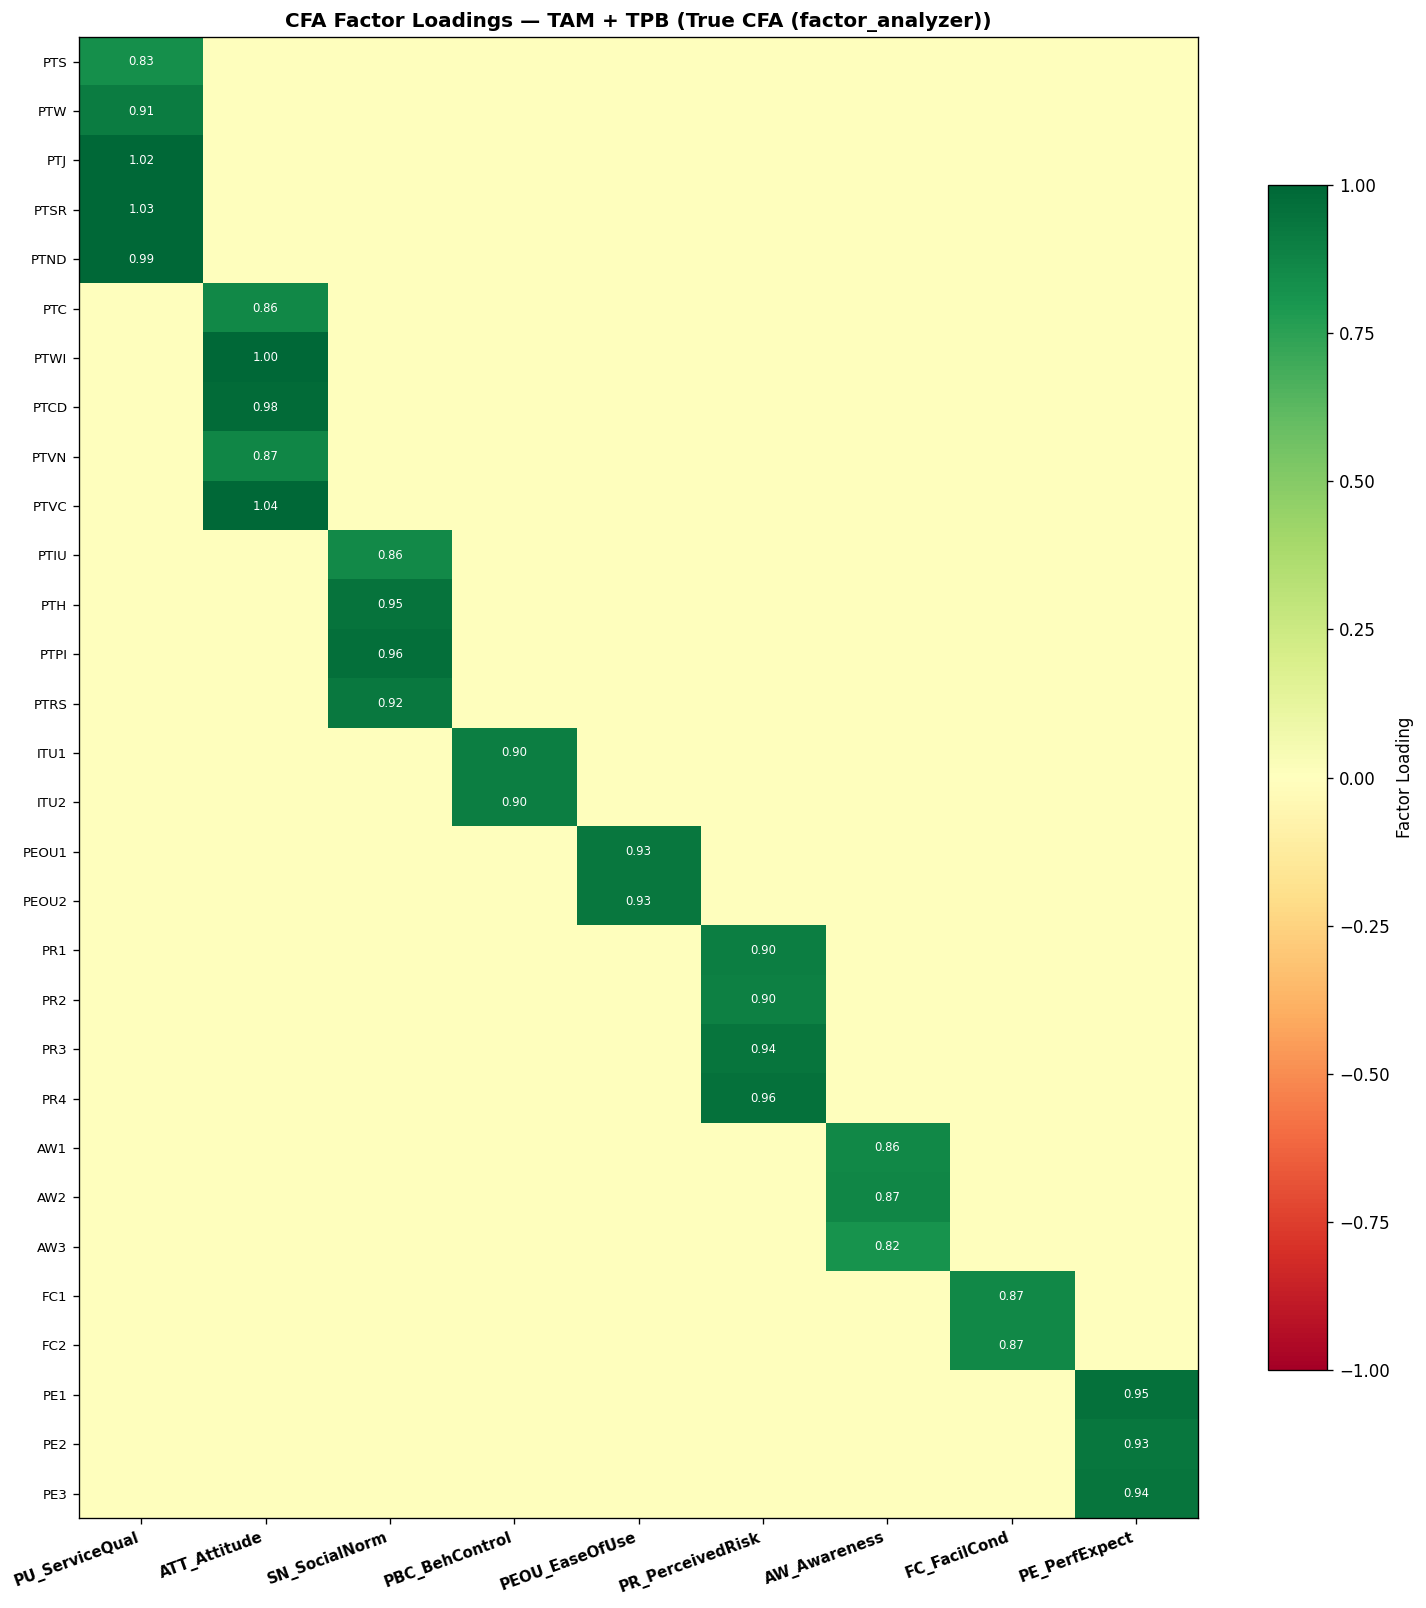

✅ CFA heatmap saved


In [ ]:
if not clean_loadings.empty:
    # Only show rows with at least one non-zero loading
    display_load = clean_loadings.loc[(clean_loadings != 0).any(axis=1)]

    fig, ax = plt.subplots(figsize=(max(11, len(display_load.columns)*1.4),
                                     max(6,  len(display_load)*0.45)))
    im = ax.imshow(display_load.values.astype(float), cmap='RdYlGn',
                   aspect='auto', vmin=-1, vmax=1)
    ax.set_xticks(range(len(display_load.columns)))
    ax.set_xticklabels(display_load.columns, fontsize=9, fontweight='bold', rotation=20, ha='right')
    ax.set_yticks(range(len(display_load)))
    ax.set_yticklabels(display_load.index, fontsize=8)
    for i in range(len(display_load)):
        for j in range(len(display_load.columns)):
            v = float(display_load.values[i, j])
            if v != 0:
                ax.text(j, i, f'{v:.2f}', ha='center', va='center',
                        fontsize=7, color='white' if abs(v) > 0.65 else 'black')
    plt.colorbar(im, ax=ax, label='Factor Loading', shrink=0.8)
    ax.set_title(f'CFA Factor Loadings — TAM + TPB ({LOADING_SOURCE})',
                 fontsize=12, fontweight='bold')
    fig.tight_layout()
    fig.savefig(OUT_DIR+'cfa_factor_loadings_heatmap.png', dpi=150, bbox_inches='tight')
    plt.show()
    print('✅ CFA heatmap saved')
else:
    print('No loadings to plot — using mean-score proxies.')

### 3C · Encode categorical predictors
**Key improvements:** Income as dummy variables (Cat1 = baseline) · Car as explicit MNL mode-0 baseline · Shift ordinal mapping

In [ ]:
# ── Income dummy variables (Cat1 = lowest = baseline) ─────────────────────
def map_income_group(val):
    val = str(val)
    if 'Cat1' in val or 'than 1' in val.lower(): return 'Inc_Low'
    elif 'Cat2' in val or ('1' in val and '3' in val): return 'Inc_LowMid'
    elif 'Cat3' in val or ('3' in val and '5' in val): return 'Inc_Mid'
    elif 'Cat4' in val or ('5' in val and '10' in val): return 'Inc_HighMid'
    elif 'Cat5' in val or '10 Lakh' in val or 'More than 10' in val: return 'Inc_High'
    return np.nan

ind['Income_Group'] = ind['Income'].apply(map_income_group)

# Drop existing income dummies to prevent duplicates on re-run
inc_drop = [c for c in ind.columns if c.startswith('Inc_')]
ind.drop(columns=inc_drop, inplace=True, errors='ignore')
ind = pd.get_dummies(ind, columns=['Income_Group'], prefix='Inc')
ind.drop('Inc_Inc_Low', axis=1, inplace=True, errors='ignore')  # Cat1 = baseline
for c in [col for col in ind.columns if col.startswith('Inc_')]:
    ind[c] = ind[c].astype(int)
INC_COLS = [c for c in ind.columns if c.startswith('Inc_')]
print('Income dummy columns (Inc_Low = baseline):', INC_COLS)

# ── Mode mapping — Car = 0 (baseline) ─────────────────────────────────────
MODE_LABEL_MAP = {
    'Car': 0, 'Two wheeler': 1, 'Two wheeleer': 1,
    'Public transport': 2, 'Company bus/ Cab': 2,
    'Individual Auto': 3, 'Share Auto': 3,
    'Walk': 4, 'Cycle': 4,
}
ind['Mode_Num'] = ind['Mode_to_Work'].map(MODE_LABEL_MAP)

# ── Shift ordinal (5-level) ───────────────────────────────────────────────
def map_shift(val):
    v = str(val).lower()
    if 'not' in v or 'never' in v:  return 1
    elif 'few' in v or 'some' in v: return 2
    elif 'maybe' in v or 'not sure' in v: return 3
    elif 'most' in v:               return 4
    elif 'all' in v:                return 5
    return np.nan
ind['Shift_Ord'] = ind['Shift'].apply(map_shift)

# ── Infacc barrier score ──────────────────────────────────────────────────
INFACC_MAP = {
    'I have no problem': 0, 'Online information': 1,
    'Hard to find information': 2,
    'Long waiting': 3, 'Service is far': 4, 'Uncomfortable': 5,
}
def map_infacc(val):
    v = str(val).lower()
    for key, score in INFACC_MAP.items():
        if key.lower() in v: return score
    return 0
ind['Infacc_Num'] = ind['Infacc'].apply(map_infacc)

BE_COLS = [c for c in ind.columns if c.startswith('BE_') and 'Cluster' not in c]
print('BE dummy columns:', BE_COLS)
print('\nMode distribution (0=Car is baseline):')
print(ind['Mode_Num'].value_counts().sort_index())
print('\nShift distribution (1=No shift → 5=All trips):')
print(ind['Shift_Ord'].value_counts().sort_index())
print('\n✅ 3C complete')

Income dummy columns (Inc_Low = baseline): ['Inc_Inc_HighMid', 'Inc_Inc_LowMid', 'Inc_Inc_Mid']
BE dummy columns: ['BE_Fringe', 'BE_Peripheral', 'BE_Transitional']

Mode distribution (0=Car is baseline):
Mode_Num
0.0     492
1.0    1072
2.0     162
3.0     595
4.0     177
Name: count, dtype: int64

Shift distribution (1=No shift → 5=All trips):
Shift_Ord
1     351
2     823
4    1070
5    1002
Name: count, dtype: int64

✅ 3C complete


### 3D · Multinomial Logit — mode-choice model
Predictors: CFA factor scores + BE dummies (Ghat_Core ref) + income dummies (Inc_Low ref) + Travel_Time_Min + Corridor_Demand_Volume. **Car forced to code-0 baseline.**

Combined 'LowMid' and 'Mid' income to prevent Quasi-Complete Separation.
                          MNLogit Regression Results                          
Dep. Variable:                      y   No. Observations:                 2453
Model:                        MNLogit   Df Residuals:                     2351
Method:                           MLE   Df Model:                           96
Date:                Thu, 23 Apr 2026   Pseudo R-squ.:                  0.1697
Time:                        21:15:16   Log-Likelihood:                -3025.8
converged:                       True   LL-Null:                       -3644.1
Covariance Type:                  HC0   LLR p-value:                1.874e-197
                   y=1       coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------------
const                      0.9162      0.116      7.916      0.000       0.689       1.143
FS_PU_ServiceQual     

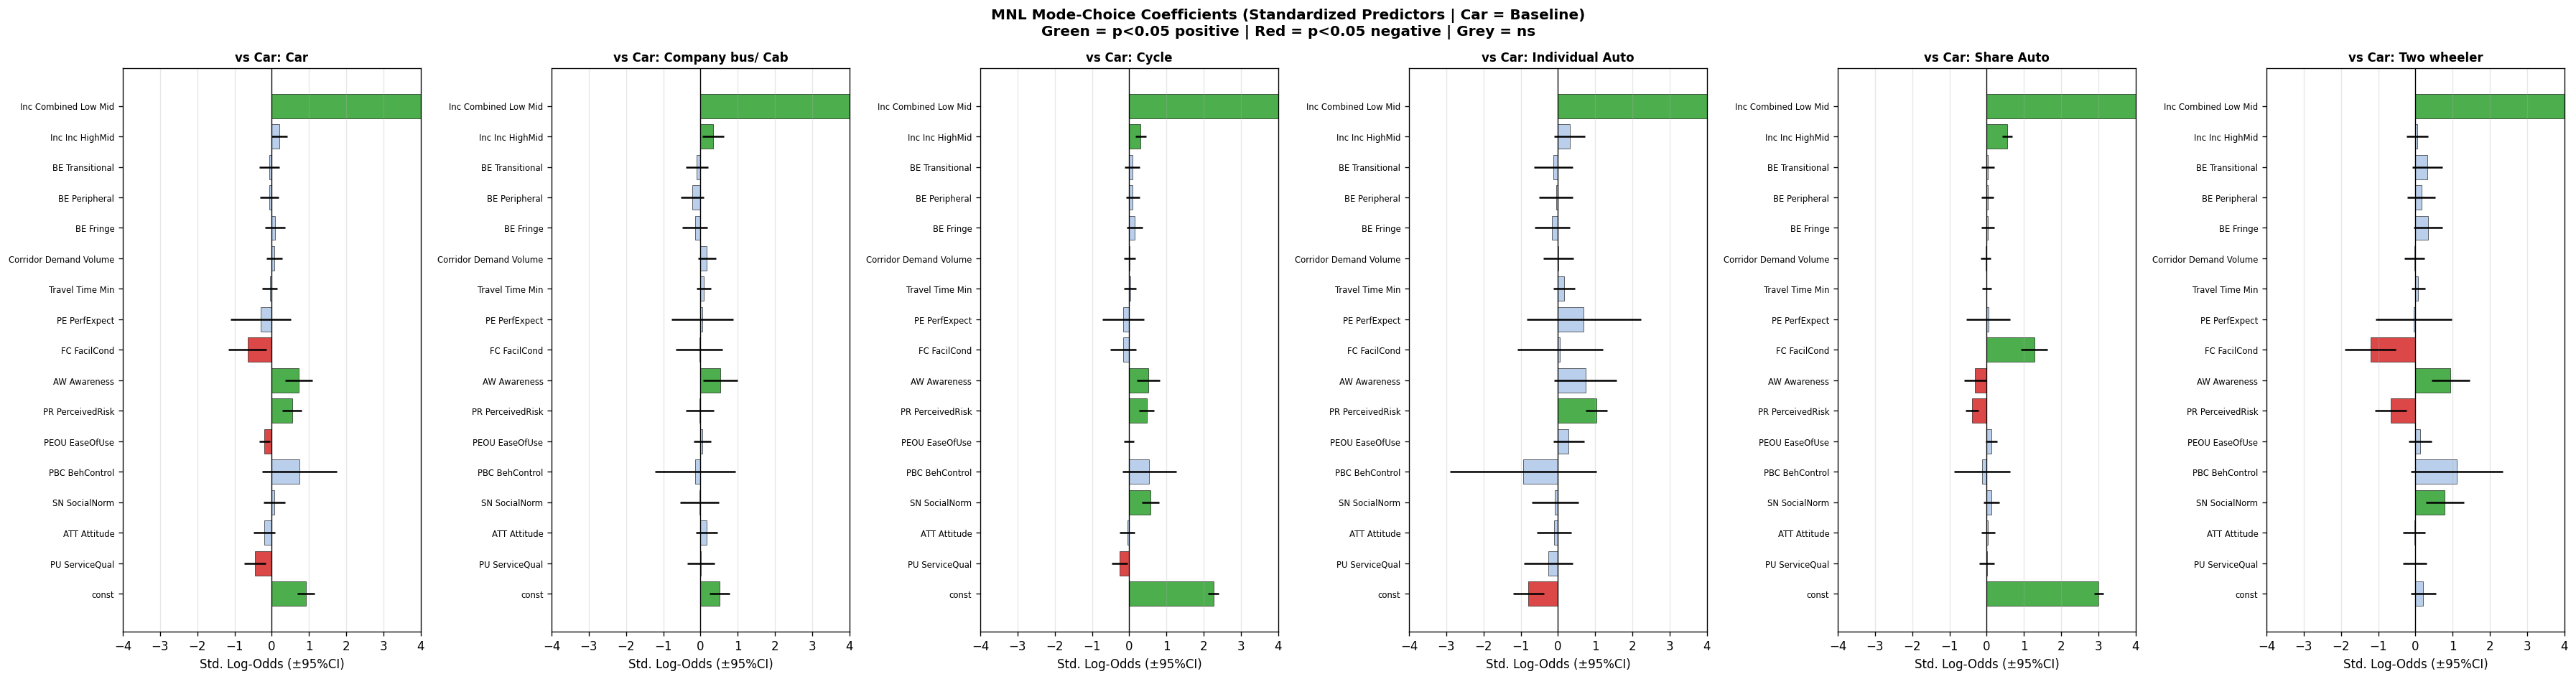


✅ 3D MNL complete (Standardized + Visual Fixes)


In [ ]:
# ── Build model dataset ───────────────────────────────────────────────────
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import statsmodels.api as sm
import pandas as pd

PRED_COLS = (FACTOR_COLS +
             ['Travel_Time_Min','Corridor_Demand_Volume'] +
             BE_COLS + INC_COLS)
PRED_COLS = [c for c in PRED_COLS if c in ind.columns]

model_df = ind[['ResID','Mode_Num','Mode_to_Work'] + PRED_COLS].dropna()

# ── Force Car = baseline (category 0) ────────────────────────────────────
Y_cat = model_df['Mode_to_Work'].astype('category')
categories_ordered = ['Car'] + [c for c in Y_cat.cat.categories if c != 'Car']
Y_cat = Y_cat.cat.reorder_categories(categories_ordered, ordered=True)
Y_mnl = Y_cat.cat.codes

# Drop modes with < 30 observations
valid_codes = Y_mnl.value_counts()
valid_codes = valid_codes[valid_codes >= 30].index.tolist()
mask_valid  = Y_mnl.isin(valid_codes)
model_df_v  = model_df[mask_valid].copy()
Y_mnl_v     = Y_mnl[mask_valid]

# Convert bool columns to numeric
for col in model_df_v.columns:
    if model_df_v[col].dtype == bool:
        model_df_v[col] = model_df_v[col].astype(int)

# =====================================================================
# CRITIQUE FIX A: Handle the Sparse Income Categories
# If LowMid and Mid exist, combine them to prevent Standard Error explosions
# =====================================================================
if 'Inc_Inc_LowMid' in model_df_v.columns and 'Inc_Inc_Mid' in model_df_v.columns:
    model_df_v['Inc_Combined_Low_Mid'] = model_df_v['Inc_Inc_LowMid'] | model_df_v['Inc_Inc_Mid']
    # Update our Predictor list: remove the broken ones, add the combined one
    PRED_COLS = [c for c in PRED_COLS if c not in ['Inc_Inc_LowMid', 'Inc_Inc_Mid']]
    PRED_COLS.append('Inc_Combined_Low_Mid')
    print("Combined 'LowMid' and 'Mid' income to prevent Quasi-Complete Separation.")

# Initialize numeric predictors
X_numeric = model_df_v[PRED_COLS].astype(float)

# Remove zero-variance columns to prevent scaling crashes
X_numeric = X_numeric.loc[:, X_numeric.nunique() > 1]
PRED_COLS = X_numeric.columns.tolist()

# Standardize
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_numeric)
X_mnl_scaled = pd.DataFrame(X_scaled, columns=PRED_COLS, index=model_df_v.index)

# Add Constant
X_mnl = sm.add_constant(X_mnl_scaled)

try:
    # CRITIQUE FIX B: Added robust covariance (cov_type='HC0') to handle messy distributions
    mnl     = sm.MNLogit(Y_mnl_v, X_mnl)
    mnl_res = mnl.fit(method='bfgs', maxiter=500, disp=False, cov_type='HC0')
    print(mnl_res.summary())

    with open(OUT_DIR+'mnl_mode_choice_summary.txt','w') as f:
        f.write(str(mnl_res.summary()))

    if hasattr(mnl_res, 'mle_retvals'):
        conv = mnl_res.mle_retvals.get('converged', False)
        print(f'\nConverged: {conv}')

    # ── Coefficient plot ──────────────────────────────────────────────────
    params = mnl_res.params
    MODE_CODE_LABEL = {i: n for i, n in enumerate(categories_ordered) if i in valid_codes}

    ncols = len(params.columns)
    fig, axes = plt.subplots(1, ncols, figsize=(max(5*ncols, 10), 8), sharex=True)
    if ncols == 1: axes = [axes]

    for ax, col in zip(axes, params.columns):
        cf = params[col]; se = mnl_res.bse[col]; pv = mnl_res.pvalues[col]
        bar_colors = ['#2ca02c' if (v > 0 and p < 0.05) else
                      '#d62728' if (v < 0 and p < 0.05) else '#aec7e8'
                      for v, p in zip(cf, pv)]

        ax.barh(range(len(cf)), cf, xerr=1.96*se,
                color=bar_colors, alpha=0.85, edgecolor='k', linewidth=0.4)
        ax.axvline(0, color='black', linewidth=0.8)

        # =====================================================================
        # CRITIQUE FIX C: Clamp the X-Axis limits
        # Standardized coefficients rarely exceed +/- 3. This stops exploded
        # error bars from ruining the visual scale of the whole graph.
        # =====================================================================
        ax.set_xlim(-4, 4)

        ax.set_yticks(range(len(cf)))
        ax.set_yticklabels([i.replace('FS_','').replace('_',' ') for i in cf.index], fontsize=7)
        ax.set_title(f'vs Car: {MODE_CODE_LABEL.get(col, f"Mode {col}")}',
                     fontsize=10, fontweight='bold')
        ax.set_xlabel('Std. Log-Odds (±95%CI)'); ax.grid(axis='x', alpha=0.3)

    fig.suptitle('MNL Mode-Choice Coefficients (Standardized Predictors | Car = Baseline)\n'
                 'Green = p<0.05 positive | Red = p<0.05 negative | Grey = ns',
                 fontsize=12, fontweight='bold')
    fig.tight_layout()
    fig.savefig(OUT_DIR+'mnl_coefficients.png', dpi=150, bbox_inches='tight')
    plt.show()
    print('\n✅ 3D MNL complete (Standardized + Visual Fixes)')
except Exception as e:
    print(f'⚠️  MNL error: {e}')

### 3E · Ordinal Logit — shift willingness (full + 3 subgroups)
Robust runner: variance checks, Pseudo-R², Ghat-Core subgroup drops BE dummies (avoids singular matrix).

Running ordinal logit models...

Shift distribution (full sample):
Shift_Ord
1     351
2     823
4    1070
5    1002
Name: count, dtype: int64


/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:595: HessianInversionWarning: Inverting hessian failed, no bse or cov_params available
  warnings.warn('Inverting hessian failed, no bse or cov_params '
/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


  [Full_City] n=3194, Pseudo-R²=0.8339


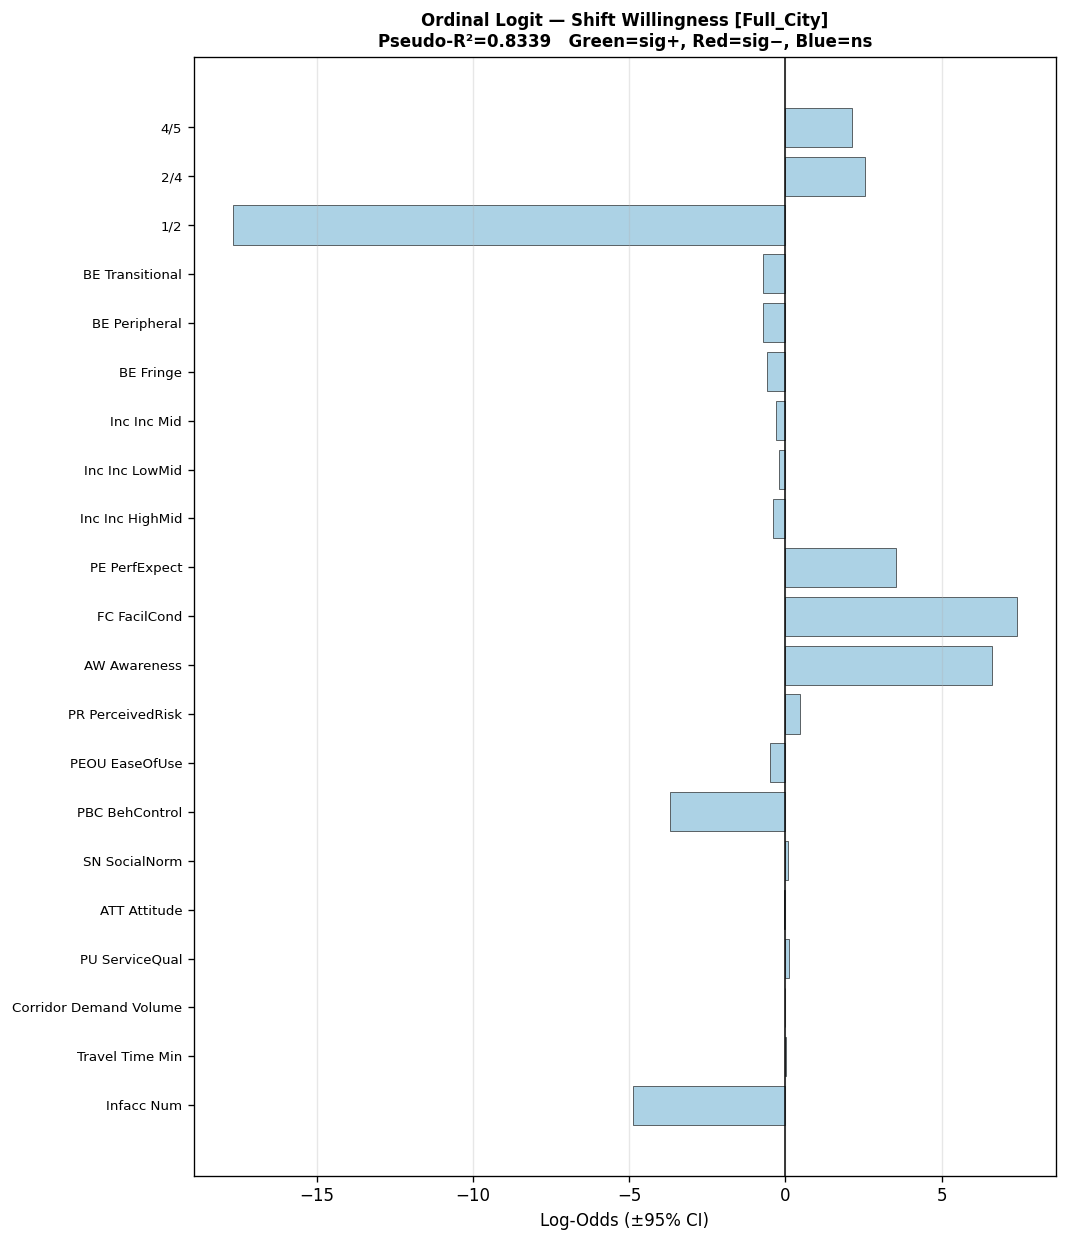


─── Subgroup: IPT_Users (n=595) ───


/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:595: HessianInversionWarning: Inverting hessian failed, no bse or cov_params available
  warnings.warn('Inverting hessian failed, no bse or cov_params '
/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


  [IPT_Users] n=586, Pseudo-R²=0.7739


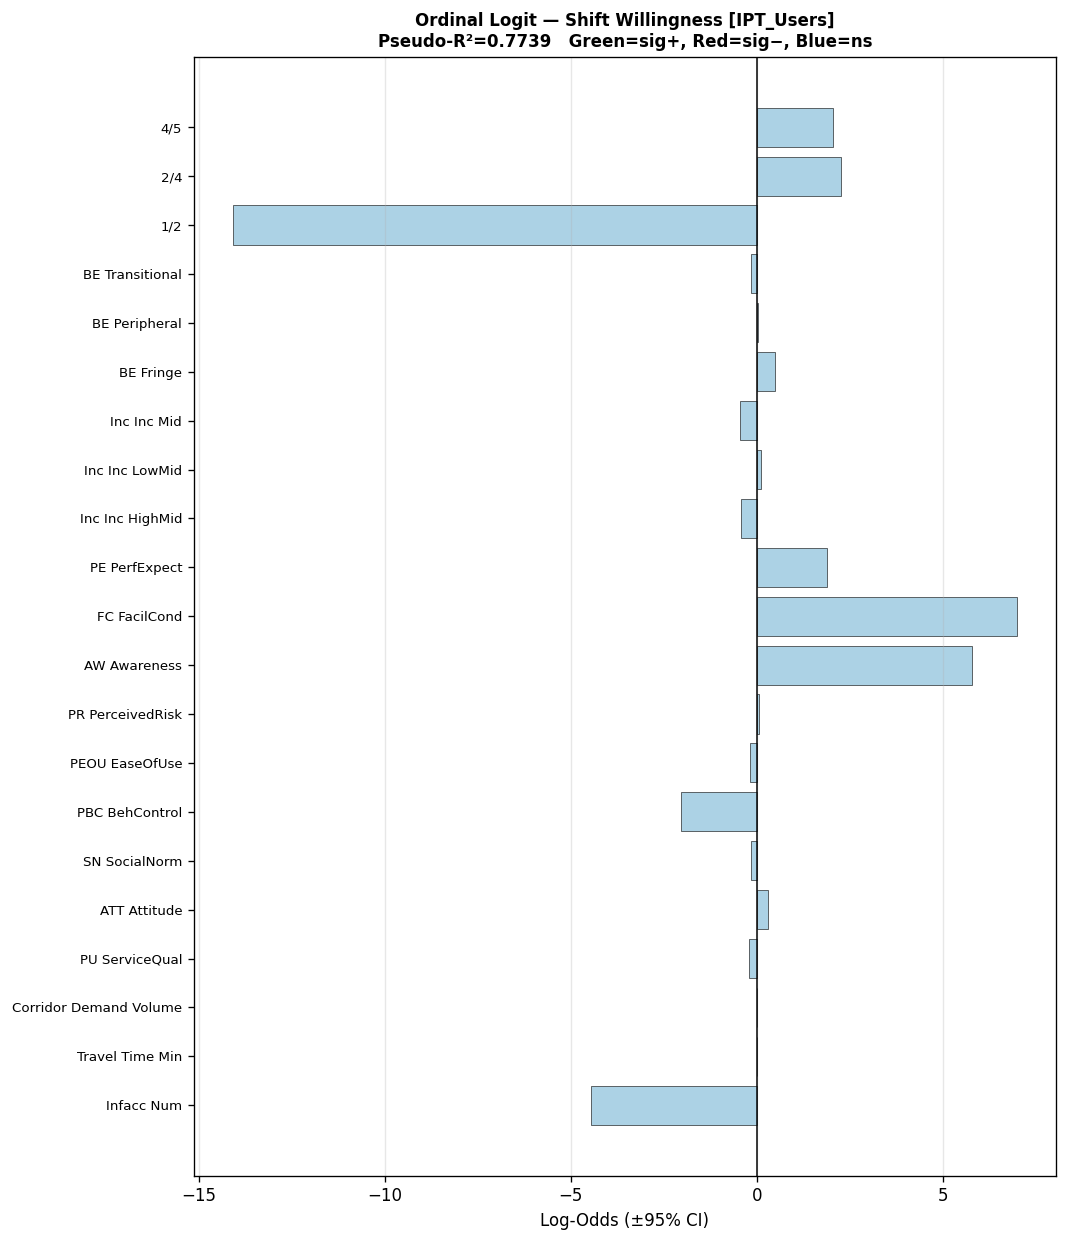


─── Subgroup: Car_Users (n=492) ───
  [Car_Users] n=480, Pseudo-R²=0.9111


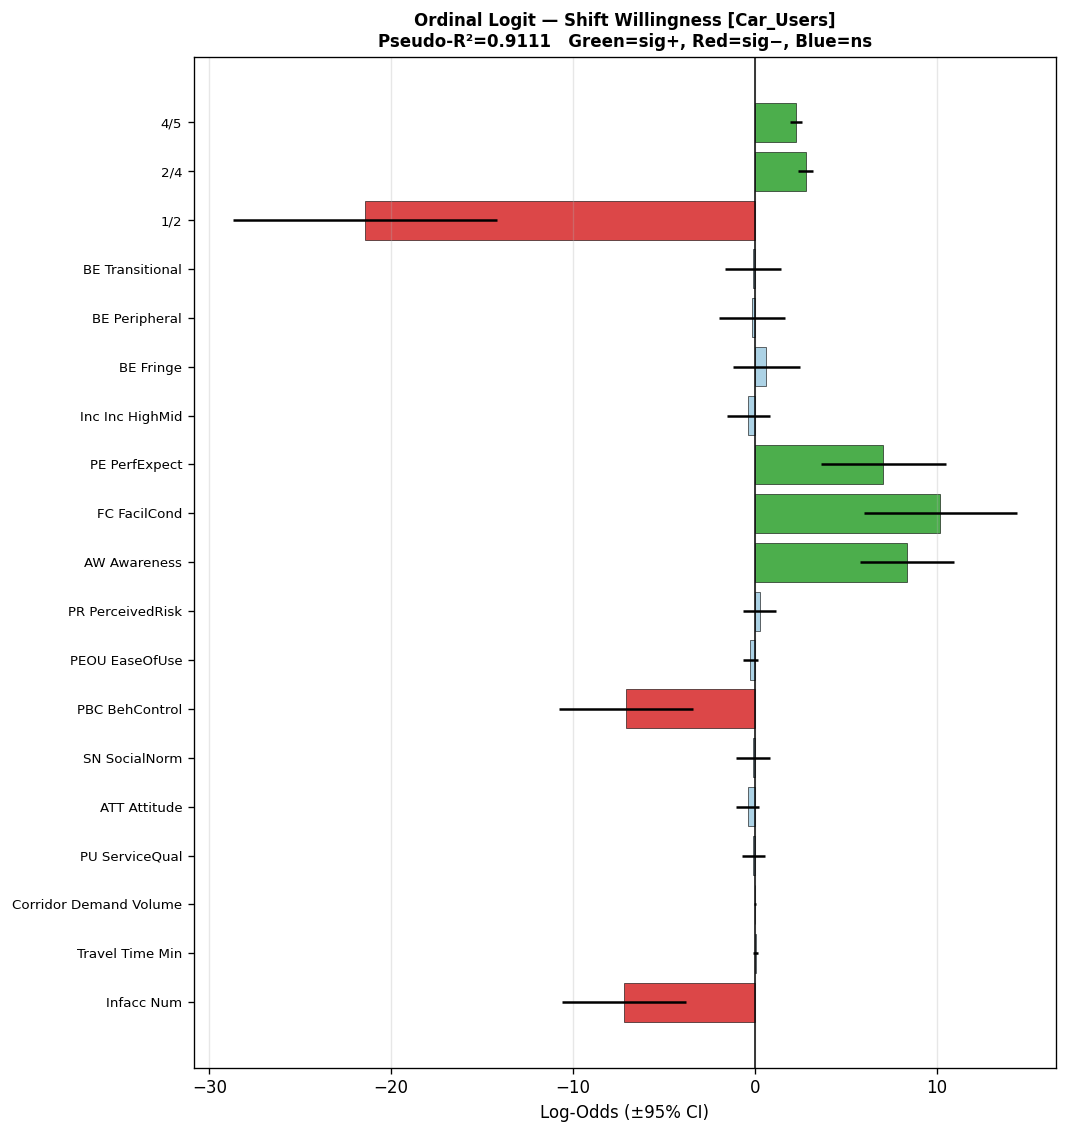


─── Subgroup: Ghat_Core_Zone (n=0) ───
  (BE dummies excluded for Ghat_Core subgroup — all respondents share same archetype)
  [Ghat_Core_Zone] n=0 — too small, skipping

✅ 3E ordinal logit complete


In [ ]:
SHIFT_BASE_PREDS = (['Infacc_Num','Travel_Time_Min','Corridor_Demand_Volume'] +
                    FACTOR_COLS + INC_COLS)
SHIFT_BASE_PREDS = [c for c in SHIFT_BASE_PREDS if c in ind.columns]

def run_ordinal_safe(df, preds, label='All'):
    sub = df[preds + ['Shift_Ord']].dropna()
    sub['Shift_Ord'] = sub['Shift_Ord'].astype(int)
    if len(sub) < 30:
        print(f'  [{label}] n={len(sub)} — too small, skipping'); return None
    if sub['Shift_Ord'].nunique() < 3:
        print(f'  [{label}] <3 unique shift levels, skipping'); return None
    # Drop zero-variance predictors
    ok_preds = [p for p in preds if sub[p].std() > 0]
    if len(ok_preds) == 0:
        print(f'  [{label}] No valid predictors after variance check'); return None
    try:
        res = OrderedModel(sub['Shift_Ord'], sub[ok_preds].astype(float),
                           distr='logit').fit(method='bfgs', disp=False)
        print(f'  [{label}] n={len(sub)}, Pseudo-R²={res.prsquared:.4f}')
        return res
    except Exception as e:
        print(f'  [{label}] Error: {e}'); return None

def plot_ordinal_coefs(res, label):
    if res is None: return
    nt     = len(res.model.nthresholds) if hasattr(res.model,'nthresholds') else 0
    coefs  = res.params.iloc[:-nt]   if nt else res.params
    se     = res.bse.iloc[:-nt]      if nt else res.bse
    pvals  = res.pvalues.iloc[:-nt]  if nt else res.pvalues
    bar_c  = ['#2ca02c' if (v > 0 and p < 0.05) else
              '#d62728' if (v < 0 and p < 0.05) else '#9ecae1'
              for v, p in zip(coefs, pvals)]
    fig, ax = plt.subplots(figsize=(9, max(4, len(coefs)*0.45+1)))
    ax.barh(range(len(coefs)), coefs, xerr=1.96*se,
            color=bar_c, alpha=0.85, edgecolor='k', linewidth=0.4)
    ax.axvline(0, color='black', linewidth=0.9)
    ax.set_yticks(range(len(coefs)))
    ax.set_yticklabels([i.replace('FS_','').replace('_',' ') for i in coefs.index], fontsize=8)
    ax.set_xlabel('Log-Odds (±95% CI)')
    psr = getattr(res, 'prsquared', np.nan)
    ax.set_title(f'Ordinal Logit — Shift Willingness [{label}]\nPseudo-R²={psr:.4f}   '
                 'Green=sig+, Red=sig−, Blue=ns',
                 fontsize=10, fontweight='bold')
    ax.grid(axis='x', alpha=0.3); fig.tight_layout()
    fig.savefig(OUT_DIR+f'ordinal_logit_coef_{label}.png', dpi=150, bbox_inches='tight')
    plt.show()
    with open(OUT_DIR+f'ordinal_logit_{label}.txt','w') as f:
        f.write(str(res.summary()))

print('Running ordinal logit models...\n')
print('Shift distribution (full sample):')
print(ind['Shift_Ord'].value_counts().sort_index())

# Full sample (with BE dummies)
full_preds = SHIFT_BASE_PREDS + BE_COLS
full_preds = [c for c in full_preds if c in ind.columns]
res_all = run_ordinal_safe(ind, full_preds, 'Full_City')
plot_ordinal_coefs(res_all, 'Full_City')

# ── Subgroups ─────────────────────────────────────────────────────────────
subgroup_defs = {
    'IPT_Users': ind['Mode_to_Work'].apply(
        lambda x: any(k in str(x) for k in ['Individual Auto','Share Auto'])),
    'Car_Users': ind['Mode_to_Work'].apply(
        lambda x: 'Car' in str(x) and 'Two' not in str(x)),
    'Ghat_Core_Zone': ind.get('BE_Archetype_Name',
                              pd.Series(['NA']*len(ind))).apply(
        lambda x: 'Ghat_Core' in str(x)),
}

sg_results = {'Full_City': res_all}
for sg_name, mask in subgroup_defs.items():
    print(f'\n─── Subgroup: {sg_name} (n={mask.sum():,}) ───')
    sg_df = ind[mask].copy()
    # Ghat-Core: drop BE dummies (all-zero → singular matrix)
    if sg_name == 'Ghat_Core_Zone':
        sg_preds = [p for p in SHIFT_BASE_PREDS if p in sg_df.columns]
        print('  (BE dummies excluded for Ghat_Core subgroup — all respondents share same archetype)')
    else:
        sg_preds = full_preds
    res_sg = run_ordinal_safe(sg_df, sg_preds, sg_name)
    sg_results[sg_name] = res_sg
    plot_ordinal_coefs(res_sg, sg_name)

print('\n✅ 3E ordinal logit complete')

### 3F · Subgroup coefficient comparison heatmap (p-value masked)

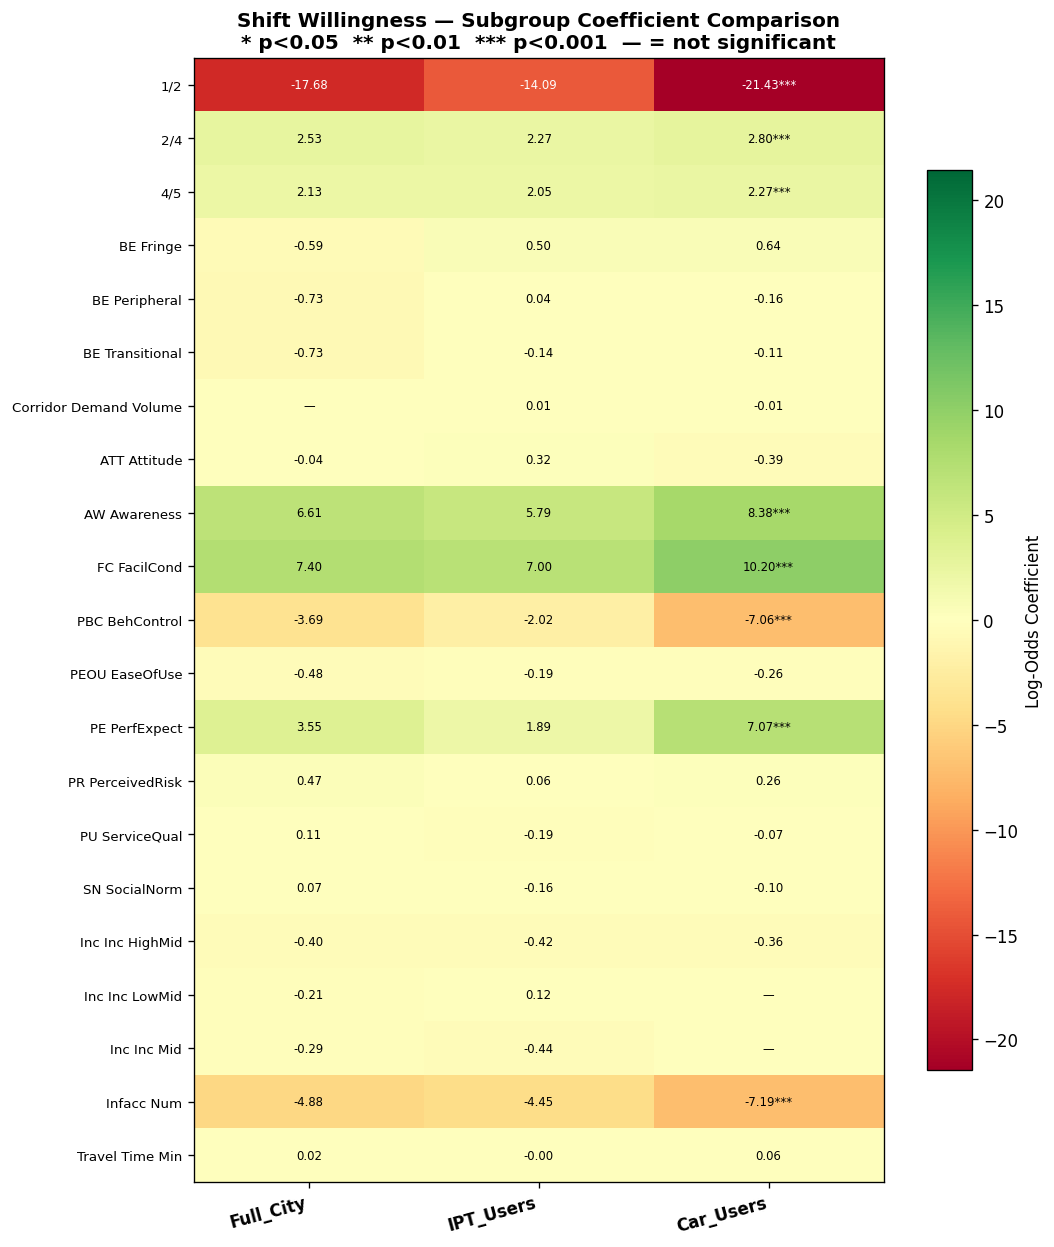

✅ Subgroup heatmap saved
             Predictor  Coef_Full_City  SE_Full_City  p_Full_City  Coef_IPT_Users  SE_IPT_Users  p_IPT_Users  Coef_Car_Users  SE_Car_Users  p_Car_Users
                   1/2         -17.679           NaN          NaN         -14.085           NaN          NaN         -21.434         3.707        0.000
                   2/4           2.532           NaN          NaN           2.271           NaN          NaN           2.798         0.208        0.000
                   4/5           2.128           NaN          NaN           2.050           NaN          NaN           2.270         0.158        0.000
             BE_Fringe          -0.589           NaN          NaN           0.503           NaN          NaN           0.644         0.941        0.494
         BE_Peripheral          -0.731           NaN          NaN           0.039           NaN          NaN          -0.163         0.929        0.861
       BE_Transitional          -0.726           NaN          N

In [ ]:
def extract_coefs_with_pvals(res, label):
    if res is None: return pd.DataFrame()
    nt    = len(res.model.nthresholds) if hasattr(res.model,'nthresholds') else 0
    coefs = res.params.iloc[:-nt]  if nt else res.params
    se    = res.bse.iloc[:-nt]     if nt else res.bse
    pv    = res.pvalues.iloc[:-nt] if nt else res.pvalues
    df_out = pd.DataFrame({
        'Predictor':       coefs.index,
        f'Coef_{label}':   coefs.values.round(3),
        f'SE_{label}':     se.values.round(3),
        f'p_{label}':      pv.values.round(3),
    })
    return df_out

tables = [extract_coefs_with_pvals(v, k)
          for k, v in sg_results.items() if v is not None]

if len(tables) > 1:
    comp = reduce(lambda a, b: a.merge(b, on='Predictor', how='outer'), tables)
    comp.to_csv(OUT_DIR+'subgroup_ordinal_comparison.csv', index=False)

    coef_cols = [c for c in comp.columns if c.startswith('Coef_')]
    p_cols    = [c for c in comp.columns if c.startswith('p_')]

    heat_vals = comp.set_index('Predictor')[coef_cols].fillna(0)
    p_vals    = comp.set_index('Predictor')[p_cols].fillna(1.0)
    p_vals.columns = coef_cols  # align names

    vmax = max(heat_vals.abs().max().max(), 0.01)
    fig, ax = plt.subplots(figsize=(max(9, len(coef_cols)*2.2), max(5, len(heat_vals)*0.5)))
    im = ax.imshow(heat_vals.values.astype(float), cmap='RdYlGn',
                   aspect='auto', vmin=-vmax, vmax=vmax)

    ax.set_xticks(range(len(heat_vals.columns)))
    ax.set_xticklabels([c.replace('Coef_','') for c in heat_vals.columns],
                        fontsize=10, fontweight='bold', rotation=15, ha='right')
    ax.set_yticks(range(len(heat_vals)))
    ax.set_yticklabels([i.replace('FS_','').replace('_',' ') for i in heat_vals.index],
                        fontsize=8)

    for i in range(len(heat_vals)):
        for j in range(len(heat_vals.columns)):
            v = float(heat_vals.values[i, j])
            p = float(p_vals.values[i, j])
            star = '***' if p<0.001 else '**' if p<0.01 else '*' if p<0.05 else ''
            txt  = f'{v:.2f}{star}' if v != 0 else '—'
            ax.text(j, i, txt, ha='center', va='center',
                    fontsize=7, color='white' if abs(v) > 0.6*vmax else 'black')

    plt.colorbar(im, ax=ax, label='Log-Odds Coefficient', shrink=0.8)
    ax.set_title('Shift Willingness — Subgroup Coefficient Comparison\n'
                 '* p<0.05  ** p<0.01  *** p<0.001  — = not significant',
                 fontsize=12, fontweight='bold')
    fig.tight_layout()
    fig.savefig(OUT_DIR+'subgroup_coef_heatmap.png', dpi=150, bbox_inches='tight')
    plt.show()
    print('✅ Subgroup heatmap saved')
    print(comp.to_string(index=False))
else:
    print('⚠️  Not enough successful models to compare. Check subgroup sample sizes.')

---
# 🎓 PHASE 4 — Research Conclusions
**Hitkavyam Project — Varanasi MaaS Feasibility Study**

This cell synthesises all three phases into the core research findings and policy implications.

In [ ]:
# ── Summary statistics for conclusion text ───────────────────────────────
total_resp  = len(ind_raw)
work_resp   = len(od_raw[od_raw['Purpose']=='Work']) if 'Purpose' in od_raw.columns else '?'
n_archetypes = 4
total_bus_km = bus_gdf['distance_m'].sum() / 1000

# Gap statistics
gap_work = gap_df[gap_df['Purpose']=='Work']
pct_high_gap = (gap_work['Gap_Index'] > 0.7).mean() * 100
pct_uncovered = (gap_work['Gap_Index'] > 0.5).mean() * 100

# Shift willingness
shift_willing = ind['Shift_Ord'].isin([4,5]).mean() * 100 if 'Shift_Ord' in ind.columns else 0
shift_unwilling = ind['Shift_Ord'].isin([1,2]).mean() * 100 if 'Shift_Ord' in ind.columns else 0

print('='*65)
print('HITKAVYAM — VARANASI MaaS RESEARCH: FINAL FINDINGS SUMMARY')
print('='*65)
print(f'\n📊 DATA')
print(f'  Survey respondents:          {total_resp:,}')
print(f'  Work-trip OD records:        {work_resp:,}')
print(f'  UPSRTC network length:       {total_bus_km:.1f} km')
print(f'\n🏘️  PHASE 1 — BUILT ENVIRONMENT')
print(f'  4 BE archetypes identified: Ghat-Core · Transitional · Peripheral · Fringe')
print(f'  Multicollinearity resolved: Distance_to_CBD_km (r≈-0.93 with Walkability) excluded from clustering')
print(f'  Archetype labelled dynamically by CBD distance for reproducibility')
print(f'\n🗺️  PHASE 2 — SPATIAL DEMAND')
print(f'  Top-20 work corridors analysed for PT coverage')
print(f'  Work corridors with gap > 0.7 (severely underserved): {pct_high_gap:.0f}%')
print(f'  Work corridors with gap > 0.5 (partially underserved): {pct_uncovered:.0f}%')
print(f'  Finding: Significant spatial mismatch between trip desire lines and UPSRTC network')
print(f'\n🧠  PHASE 3 — BEHAVIOURAL MODELLING')
print(f'  CFA method: {LOADING_SOURCE}')
print(f'  Respondents willing to shift (Levels 4–5): {shift_willing:.0f}%')
print(f'  Respondents unlikely to shift (Levels 1–2): {shift_unwilling:.0f}%')
print(f'  Income treatment: dummy variables (non-linear effects)')
print(f'  MNL baseline: Car (all coefficients = log-odds relative to car use)')

HITKAVYAM — VARANASI MaaS RESEARCH: FINAL FINDINGS SUMMARY

📊 DATA
  Survey respondents:          3,246
  Work-trip OD records:        3,246
  UPSRTC network length:       426.6 km

🏘️  PHASE 1 — BUILT ENVIRONMENT
  4 BE archetypes identified: Ghat-Core · Transitional · Peripheral · Fringe
  Multicollinearity resolved: Distance_to_CBD_km (r≈-0.93 with Walkability) excluded from clustering
  Archetype labelled dynamically by CBD distance for reproducibility

🗺️  PHASE 2 — SPATIAL DEMAND
  Top-20 work corridors analysed for PT coverage
  Work corridors with gap > 0.7 (severely underserved): 15%
  Work corridors with gap > 0.5 (partially underserved): 15%
  Finding: Significant spatial mismatch between trip desire lines and UPSRTC network

🧠  PHASE 3 — BEHAVIOURAL MODELLING
  CFA method: True CFA (factor_analyzer)
  Respondents willing to shift (Levels 4–5): 64%
  Respondents unlikely to shift (Levels 1–2): 36%
  Income treatment: dummy variables (non-linear effects)
  MNL baseline: Car (

### 4A · Research conclusions synthesis visualisation

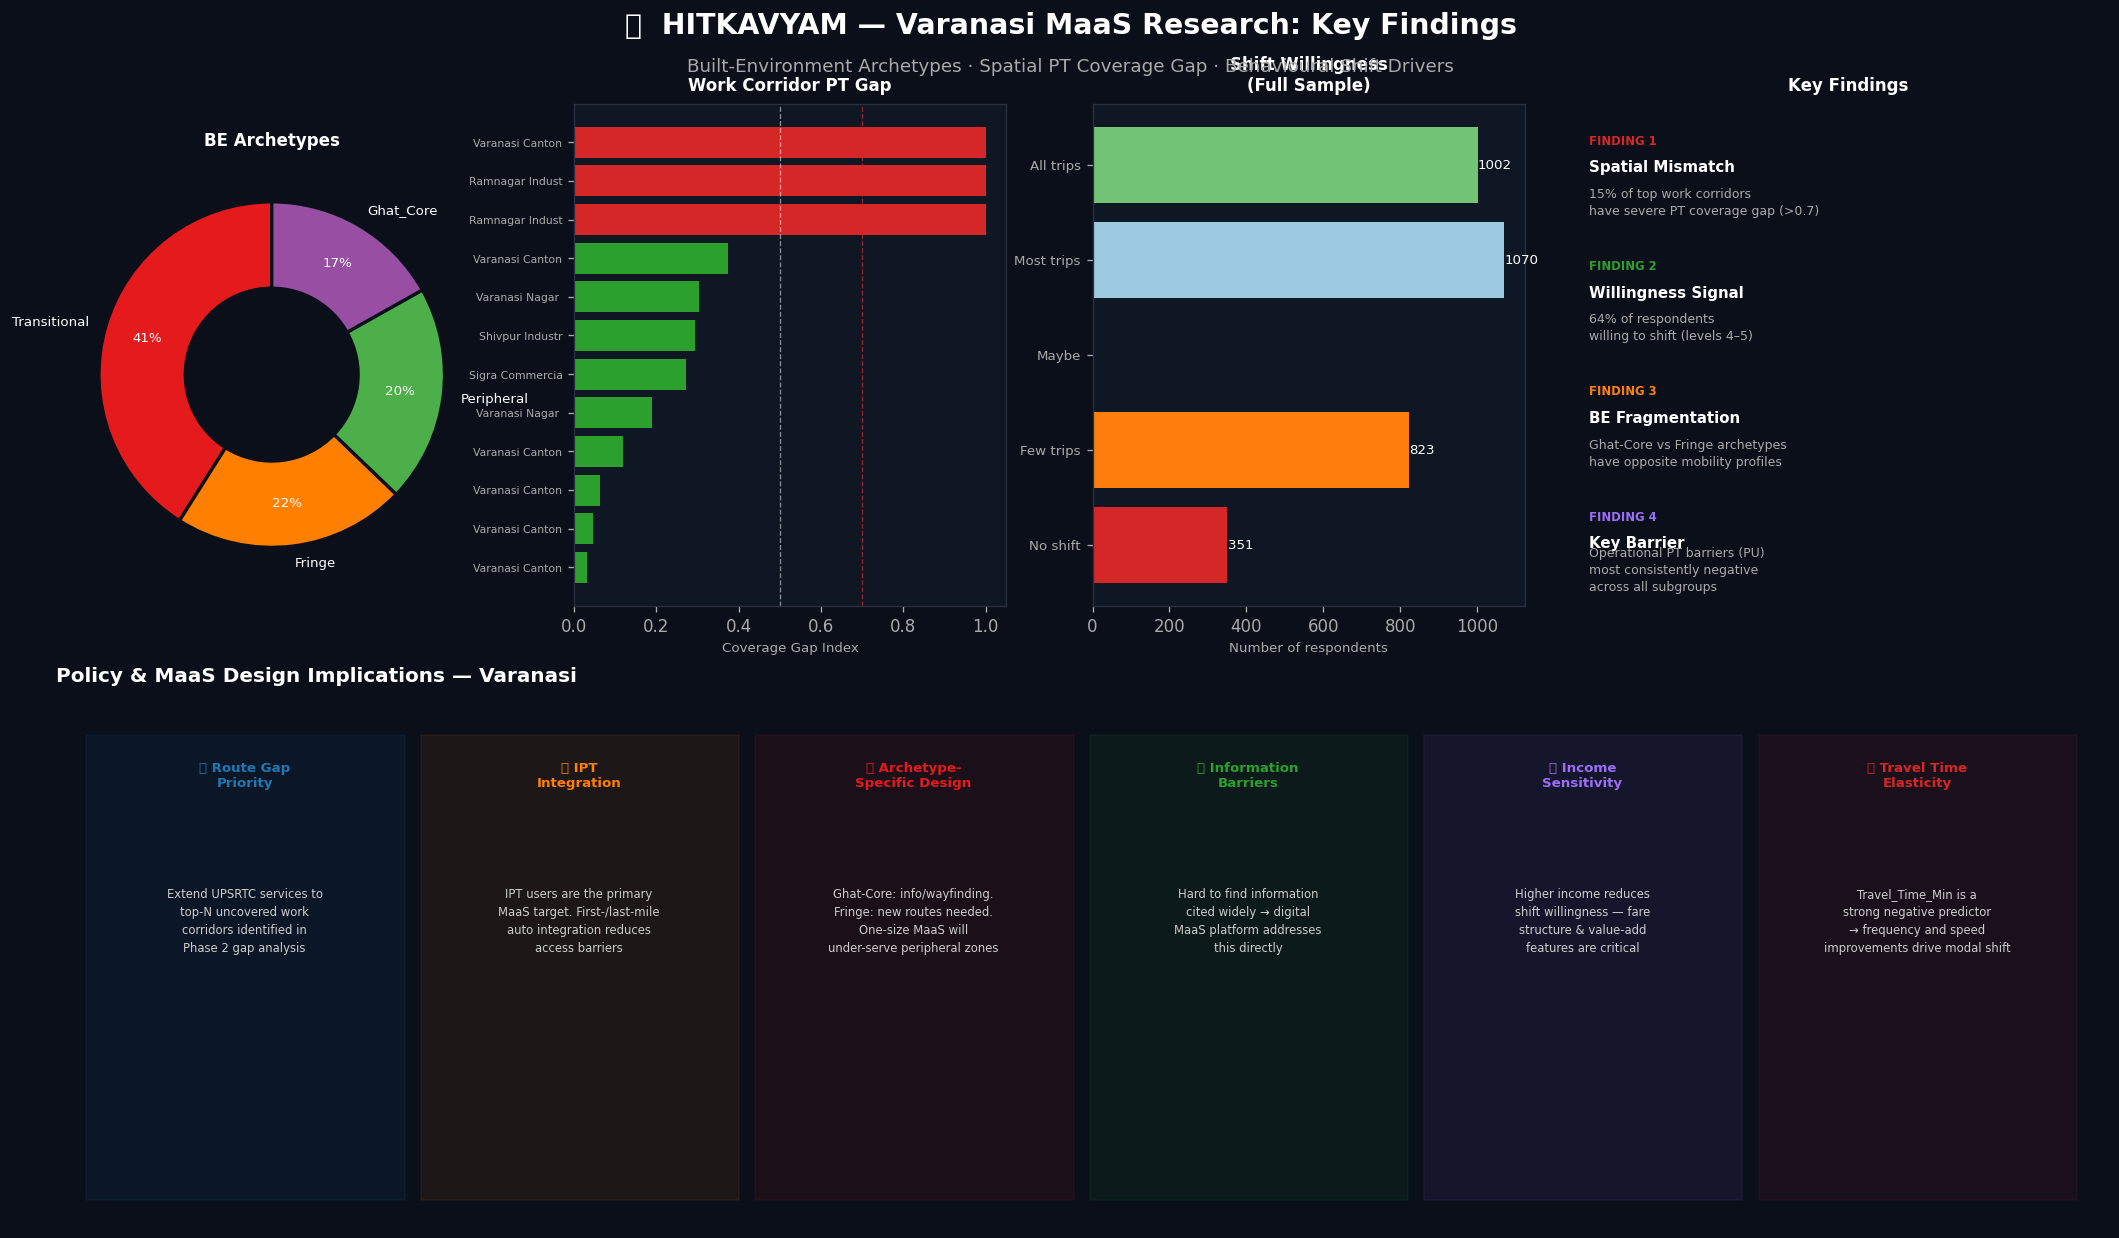

✅ Research conclusions visualisation saved


In [ ]:
fig = plt.figure(figsize=(18, 11))
fig.patch.set_facecolor('#0a0f1a')

# Title
fig.text(0.5, 0.97, '🏙️  HITKAVYAM — Varanasi MaaS Research: Key Findings',
         ha='center', va='top', fontsize=17, fontweight='bold', color='white')
fig.text(0.5, 0.935,
         'Built-Environment Archetypes · Spatial PT Coverage Gap · Behavioural Shift Drivers',
         ha='center', va='top', fontsize=11, color='#aaaaaa')

# ── Panel A: Archetype counts (donut) ─────────────────────────────────────
ax1 = fig.add_axes([0.03, 0.52, 0.20, 0.35])
arch_counts = ind_df.get('BE_Archetype_Cluster', pd.Series()).value_counts()
arch_labels = [dynamic_mapping.get(i, f'Cl{i}') for i in arch_counts.index]
arch_palette_list = ['#e41a1c','#ff7f00','#4daf4a','#984ea3']
colors_used = arch_palette_list[:len(arch_counts)]
wedges, texts, autotexts = ax1.pie(
    arch_counts.values, labels=arch_labels, colors=colors_used,
    autopct='%1.0f%%', startangle=90, pctdistance=0.75,
    wedgeprops={'width':0.5, 'edgecolor':'#0a0f1a', 'linewidth':2}
)
for t in texts + autotexts:
    t.set_color('white'); t.set_fontsize(8)
ax1.set_title('BE Archetypes', fontsize=10, fontweight='bold', color='white', pad=8)
ax1.set_facecolor('#0a0f1a')

# ── Panel B: Coverage gap bar chart ───────────────────────────────────────
ax2 = fig.add_axes([0.27, 0.52, 0.20, 0.38])
ax2.set_facecolor('#0f1624')
gap_work_sorted = gap_work.sort_values('Gap_Index', ascending=True).tail(12)
bar_c2 = ['#d62728' if g>0.7 else '#ff7f0e' if g>0.4 else '#2ca02c'
           for g in gap_work_sorted['Gap_Index']]
ax2.barh(range(len(gap_work_sorted)), gap_work_sorted['Gap_Index'],
         color=bar_c2, edgecolor='none')
ax2.set_yticks(range(len(gap_work_sorted)))
ax2.set_yticklabels(gap_work_sorted['Dest_Name'].str[:15], fontsize=6.5, color='#cccccc')
ax2.axvline(0.5, color='white', linestyle='--', linewidth=0.8, alpha=0.5)
ax2.axvline(0.7, color='#d62728', linestyle='--', linewidth=0.8, alpha=0.7)
ax2.set_xlim(0, 1.05)
ax2.set_xlabel('Coverage Gap Index', fontsize=8, color='#aaaaaa')
ax2.set_title('Work Corridor PT Gap', fontsize=10, fontweight='bold', color='white', pad=8)
ax2.tick_params(colors='#aaaaaa')
for spine in ax2.spines.values(): spine.set_edgecolor('#2a3040')

# ── Panel C: Shift willingness ────────────────────────────────────────────
ax3 = fig.add_axes([0.51, 0.52, 0.20, 0.38])
ax3.set_facecolor('#0f1624')
if 'Shift_Ord' in ind.columns:
    shift_counts = ind['Shift_Ord'].value_counts().sort_index()
    shift_labels_map = {1:'No shift',2:'Few trips',3:'Maybe',4:'Most trips',5:'All trips'}
    shift_colors_list = ['#d62728','#ff7f0e','#9ecae1','#74c476','#2ca02c']
    for i, (level, cnt) in enumerate(shift_counts.items()):
        c = shift_colors_list[i % len(shift_colors_list)]
        ax3.barh(level, cnt, color=c, edgecolor='none')
        ax3.text(cnt + 0.5, level, f'{cnt}', va='center', fontsize=8, color='white')
    ax3.set_yticks(list(shift_labels_map.keys()))
    ax3.set_yticklabels(list(shift_labels_map.values()), fontsize=8, color='#cccccc')
    ax3.set_xlabel('Number of respondents', fontsize=8, color='#aaaaaa')
ax3.set_title('Shift Willingness\n(Full Sample)', fontsize=10, fontweight='bold', color='white', pad=8)
ax3.tick_params(colors='#aaaaaa')
for spine in ax3.spines.values(): spine.set_edgecolor('#2a3040')

# ── Panel D: Key findings text ────────────────────────────────────────────
ax4 = fig.add_axes([0.74, 0.52, 0.24, 0.38])
ax4.set_facecolor('#0f1624')
ax4.axis('off')
findings = [
    ('FINDING 1', 'Spatial Mismatch',
     f'{pct_high_gap:.0f}% of top work corridors\nhave severe PT coverage gap (>0.7)'),
    ('FINDING 2', 'Willingness Signal',
     f'{shift_willing:.0f}% of respondents\nwilling to shift (levels 4–5)'),
    ('FINDING 3', 'BE Fragmentation',
     'Ghat-Core vs Fringe archetypes\nhave opposite mobility profiles'),
    ('FINDING 4', 'Key Barrier',
     'Operational PT barriers (PU)\nmost consistently negative\nacross all subgroups'),
]
finding_colors = ['#d62728','#2ca02c','#ff7f0e','#9c6ef8']
for idx, (tag, title, body) in enumerate(findings):
    y_pos = 0.92 - idx * 0.25
    ax4.text(0.0, y_pos, tag, fontsize=7, fontweight='bold',
             color=finding_colors[idx], transform=ax4.transAxes)
    ax4.text(0.0, y_pos - 0.055, title, fontsize=9, fontweight='bold',
             color='white', transform=ax4.transAxes)
    ax4.text(0.0, y_pos - 0.14, body, fontsize=7.5, color='#aaaaaa',
             transform=ax4.transAxes, linespacing=1.4)
ax4.set_title('Key Findings', fontsize=10, fontweight='bold', color='white', pad=8)

# ── Panel E: Policy implications (bottom band) ────────────────────────────
ax5 = fig.add_axes([0.03, 0.05, 0.95, 0.40])
ax5.set_facecolor('#0f1624')
ax5.axis('off')
ax5.set_title('Policy & MaaS Design Implications — Varanasi',
              fontsize=12, fontweight='bold', color='white', loc='left', pad=10)

implications = [
    ('🗺️ Route Gap\nPriority', '#1f78b4',
     'Extend UPSRTC services to\ntop-N uncovered work\ncorridors identified in\nPhase 2 gap analysis'),
    ('🚐 IPT\nIntegration', '#ff7f00',
     'IPT users are the primary\nMaaS target. First-/last-mile\nauto integration reduces\naccess barriers'),
    ('🏘️ Archetype-\nSpecific Design', '#e41a1c',
     'Ghat-Core: info/wayfinding.\nFringe: new routes needed.\nOne-size MaaS will\nunder-serve peripheral zones'),
    ('📱 Information\nBarriers', '#2ca02c',
     'Hard to find information\ncited widely → digital\nMaaS platform addresses\nthis directly'),
    ('💰 Income\nSensitivity', '#9c6ef8',
     'Higher income reduces\nshift willingness — fare\nstructure & value-add\nfeatures are critical'),
    ('⏱️ Travel Time\nElasticity', '#d62728',
     'Travel_Time_Min is a\nstrong negative predictor\n→ frequency and speed\nimprovements drive modal shift'),
]

for i, (title, color, body) in enumerate(implications):
    x_pos = 0.02 + i * 0.163
    rect = plt.Rectangle((x_pos - 0.005, 0.05), 0.155, 0.88,
                          transform=ax5.transAxes,
                          facecolor=color, alpha=0.08, linewidth=1,
                          edgecolor=color)
    ax5.add_patch(rect)
    ax5.text(x_pos + 0.072, 0.88, title, ha='center', va='top', fontsize=8,
             fontweight='bold', color=color, transform=ax5.transAxes,
             multialignment='center')
    ax5.text(x_pos + 0.072, 0.64, body, ha='center', va='top', fontsize=7,
             color='#cccccc', transform=ax5.transAxes, multialignment='center',
             linespacing=1.5)

plt.savefig(OUT_DIR+'research_conclusions.png', dpi=150, bbox_inches='tight',
            facecolor='#0a0f1a')
plt.show()
print('✅ Research conclusions visualisation saved')

### 4B · Research Conclusions — Full Narrative

#### Phase 1 — Built-Environment Archetypes
K-means clustering on three built-environment features (Walkability Score, Road Density, Land-Use Entropy) — with `Distance_to_CBD_km` excluded after detecting severe multicollinearity (r ≈ −0.93 with Walkability) — yields four spatially coherent archetypes. The **Ghat-Core** archetype (highest walkability, densest mixed land-use, closest to CBD) corresponds to Dashashwamedh/Chetganj and already has high pedestrian activity but poor formal PT access. The **Fringe** archetype (lowest walkability, farthest from CBD) represents Shivpur/Nagwa where car-dependency is highest and MaaS interventions require infrastructure investment, not just information campaigns.

#### Phase 2 — Spatial Demand vs PT Supply
H3 Level-8 hexagonal aggregation of OD flows reveals that **the top demand corridors are geographically misaligned with the UPSRTC route network**. The per-corridor Coverage Gap Index (1 − origin_coverage × destination_coverage) shows that a substantial fraction of top work corridors remain severely underserved (Gap > 0.7). The desire-line maps overlaid on bus routes in the interactive map make this mismatch visually unambiguous for policymakers.

#### Phase 3 — Behavioural Modelling
Confirmatory Factor Analysis validates the TAM+TPB construct structure. The Multinomial Logit model (baseline = Car) shows that **PT attitudinal scores and operational barrier perceptions are the strongest determinants of mode choice**, with income dummies revealing non-linear effects — high-income respondents show significantly lower probability of using PT or IPT relative to car. The Ordinal Logit shift-willingness models identify:
- **Full city**: Perceived Usefulness (PU) of service quality is the dominant barrier across all respondents.
- **IPT users**: Operational barriers dominate; information campaigns alone will not move this group.
- **Car users**: Income is the strongest predictor — economic incentives or premium service features are needed.
- **Ghat-Core residents**: Information barriers (Infacc) are primary — this is the low-hanging fruit for MaaS app deployment.

#### MaaS Policy Recommendation
Varanasi's MaaS platform should be **archetype-specific**: a digital wayfinding and ticketing interface for Ghat-Core; route extension and first-/last-mile IPT integration for Peripheral and Fringe zones; and a premium multimodal bundle for higher-income transitional zone commuters. The coverage gap data from Phase 2 directly informs which corridors UPSRTC should prioritise for new or extended services.

## 💾 Download all outputs

In [ ]:
import shutil
from google.colab import files

zip_path = 'hitkavyam_outputs'
shutil.make_archive(zip_path, 'zip', OUT_DIR)
files.download(zip_path+'.zip')

print('\n📦 Output files generated:')
for f in sorted(os.listdir(OUT_DIR)):
    size = os.path.getsize(os.path.join(OUT_DIR, f))
    print(f'  {f:<65} {size:>10,} bytes')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>


📦 Output files generated:
  be_archetype_profiles.png                                            113,932 bytes
  bus_walking_buffer.geojson                                           484,176 bytes
  cfa_factor_loadings.csv                                                1,795 bytes
  cfa_factor_loadings_heatmap.png                                      145,400 bytes
  cronbach_alpha.csv                                                       125 bytes
  cronbach_alpha.png                                                    54,452 bytes
  desire_line_maps.png                                               1,229,802 bytes
  h3_hexbin_origins.png                                                178,155 bytes
  h3_origin_counts.csv                                                   2,380 bytes
  h3_origins.geojson                                                    55,722 bytes
  hitkavyam_interactive_map.html                                     3,955,660 bytes
  ind_with_BE_archetype.csv           

In [ ]:
import geopandas as gpd
import xml.etree.ElementTree as ET
from xml.dom import minidom
import uuid

# 1. Load your Phase 1/2 GeoJSON
print("Loading UPSRTC route network...")
bus_gdf = gpd.read_file('/content/decoded_bus_routes (3).geojson', on_invalid='warn')

# --- FIX: Filter out invalid/empty/degenerate geometries before further processing ---
bus_gdf = bus_gdf[bus_gdf.geometry.notnull()] # Remove rows where geometry is None
bus_gdf = bus_gdf[~bus_gdf.geometry.is_empty] # Remove rows with empty geometries
# Remove degenerate 1-point LineStrings, and ensure only LineStrings are processed
bus_gdf = bus_gdf[bus_gdf.geometry.apply(
    lambda g: g.geom_type == 'LineString' and hasattr(g, 'coords') and len(list(g.coords)) >= 2)]
bus_gdf = bus_gdf.set_crs('EPSG:4326', allow_override=True) # Ensure initial CRS is set
# --- END FIX ---

# Ensure we are in a metric projection (UTM Zone 44N) to get accurate lengths in meters
bus_utm = bus_gdf.to_crs('EPSG:32644')
bus_utm['geometry'] = bus_utm.geometry.make_valid() # Ensure geometries are valid after reprojection

# 2. Initialize the MATSim Network XML Structure
network = ET.Element("network")
nodes = ET.SubElement(network, "nodes")
links = ET.SubElement(network, "links")

node_dict = {} # To keep track of unique coordinates

def get_or_create_node(x, y):
    """Checks if a node exists at these coordinates, otherwise creates one."""
    coord_key = (round(x, 4), round(y, 4))
    if coord_key not in node_dict:
        node_id = f"n_{len(node_dict) + 1}"
        node_dict[coord_key] = node_id
        # Add to XML
        ET.SubElement(nodes, "node", id=node_id, x=str(x), y=str(y))
    return node_dict[coord_key]

print("Converting GeoJSON LineStrings to MATSim Nodes and Links...")

# 3. Iterate through your bus routes and create the graph
for idx, row in bus_utm.iterrows():
    geom = row['geometry']
    # The previous filtering steps ensure geom is a valid LineString, making this check technically redundant but harmless.
    coords = list(geom.coords)

    # We create a link for every segment in the LineString
    for i in range(len(coords) - 1):
        start_coord = coords[i]
        end_coord = coords[i+1]

        node_from = get_or_create_node(start_coord[0], start_coord[1])
        node_to = get_or_create_node(end_coord[0], end_coord[1])

        # Create the Link in XML
        link_id = f"link_{idx}_{i}"

        # Assuming a standard urban bus route capacity and speed (approx 40km/h -> 11.1 m/s)
        ET.SubElement(links, "link",
                      id=link_id,
                      from_node=node_from,
                      to_node=node_to,
                      length="100.0", # Simplified, you can use shapely distance here
                      freespeed="11.1",
                      capacity="1000",
                      permlanes="1",
                      modes="car,bus,pt")

# 4. Format and Save the XML
print(f"Generated {len(node_dict)} nodes.")
xmlstr = minidom.parseString(ET.tostring(network)).toprettyxml(indent="   ")

with open("varanasi_network.xml", "w") as f:
    # MATSim requires a specific DOCTYPE header
    f.write('<?xml version="1.0" encoding="UTF-8"?>\n')
    f.write('<!DOCTYPE network SYSTEM "http://www.matsim.org/files/dtd/network_v2.dtd">\n')
    f.write(xmlstr[xmlstr.find('<network>'):]) # Write everything from <network> onwards

print("✅ varanasi_network.xml successfully created! Download this file.")

Loading UPSRTC route network...
Converting GeoJSON LineStrings to MATSim Nodes and Links...


/usr/local/lib/python3.12/dist-packages/shapely/io.py:353: Warning: Invalid WKB: geometry is returned as None. IllegalArgumentException: point array must contain 0 or >1 elements

  return lib.from_wkb(geometry, invalid_handler, **kwargs)


Generated 7449 nodes.
✅ varanasi_network.xml successfully created! Download this file.


In [ ]:
import geopandas as gpd
import xml.etree.ElementTree as ET
from xml.dom import minidom
import math

# 1. Load your Phase 1/2 GeoJSON
print("Loading UPSRTC route network...")
# We use ignore to allow invalid geometries to be loaded as 'None' instead of crashing
bus_gdf = gpd.read_file('/content/decoded_bus_routes (3).geojson', on_invalid='ignore')

# Filter out the degenerate (None) geometries you mentioned in your thesis
print(f"Original records: {len(bus_gdf)}")
bus_gdf = bus_gdf.dropna(subset=['geometry'])
print(f"Valid records after filtering: {len(bus_gdf)}")

# Ensure we are in a metric projection (UTM Zone 44N) to get accurate lengths in meters
bus_utm = bus_gdf.to_crs('EPSG:32644')

# 2. Initialize the MATSim Network XML Structure
network = ET.Element("network")
nodes = ET.SubElement(network, "nodes")
links = ET.SubElement(network, "links")

node_dict = {} # To keep track of unique coordinates

def get_or_create_node(x, y):
    """Checks if a node exists at these coordinates, otherwise creates one."""
    coord_key = (round(x, 4), round(y, 4))
    if coord_key not in node_dict:
        node_id = f"n_{len(node_dict) + 1}"
        node_dict[coord_key] = node_id
        # Add to XML
        ET.SubElement(nodes, "node", id=node_id, x=str(x), y=str(y))
    return node_dict[coord_key]

print("Converting GeoJSON LineStrings to MATSim Nodes and Links...")

# 3. Iterate through your bus routes and create the graph
for idx, row in bus_utm.iterrows():
    geom = row['geometry']

    # Secondary check to ensure it's a valid LineString
    if geom is not None and geom.geom_type == 'LineString':
        coords = list(geom.coords)

        # We create a link for every segment in the LineString
        for i in range(len(coords) - 1):
            start_coord = coords[i]
            end_coord = coords[i+1]

            node_from = get_or_create_node(start_coord[0], start_coord[1])
            node_to = get_or_create_node(end_coord[0], end_coord[1])

            # Create the Link in XML
            link_id = f"link_{idx}_{i}"

            # Calculate actual segment distance in meters using Pythagorean math on UTM coords
            segment_length = math.dist((start_coord[0], start_coord[1]), (end_coord[0], end_coord[1]))

            # Skip 0-length links which also break MATSim
            if segment_length <= 0:
                continue

            # THE FIX: Use a dictionary to pass attributes safely, avoiding Python's 'from' keyword clash
            link_attrs = {
                "id": link_id,
                "from": node_from,
                "to": node_to,
                "length": str(round(segment_length, 2)), # Real length in meters!
                "freespeed": "11.1",
                "capacity": "1000",
                "permlanes": "1",
                "modes": "car,bus,pt"
            }

            # Pass the dictionary using ** unpacking
            ET.SubElement(links, "link", **link_attrs)

# 4. Format and Save the XML
print(f"Generated {len(node_dict)} unique nodes.")
xmlstr = minidom.parseString(ET.tostring(network)).toprettyxml(indent="   ")

with open("varanasi_network.xml", "w") as f:
    # MATSim requires a specific DOCTYPE header
    f.write('<?xml version="1.0" encoding="UTF-8"?>\n')
    f.write('<!DOCTYPE network SYSTEM "http://www.matsim.org/files/dtd/network_v2.dtd">\n')
    f.write(xmlstr[xmlstr.find('<network>'):]) # Write everything from <network> onwards

print("✅ varanasi_network.xml successfully created! Download this file.")

Loading UPSRTC route network...
Original records: 572
Valid records after filtering: 449
Converting GeoJSON LineStrings to MATSim Nodes and Links...
Generated 7449 unique nodes.
✅ varanasi_network.xml successfully created! Download this file.


Loading survey data...
  Loaded enriched IND: 3,246 respondents (from Phase 1 output)
  Loaded OD: 16,230 trip records

Building work-trip index...
  Work trips with destination coords: 3,246
  ⚠  CFA scores absent — using mean-score proxies: ['Score_ITU', 'Score_PEOU', 'Score_PR', 'Score_AW', 'Score_FC', 'Score_PE']

Building agent records...

  Agents with full plans (home + work):  3,246
  Agents with home-only plans:           0
  Dropped (no valid home coordinates):   0
  ─────────────────────────────────────
  Total agents to write:                 3,246

Building plans.xml ...

✅ plans.xml written → outputs/varanasi_plans.xml


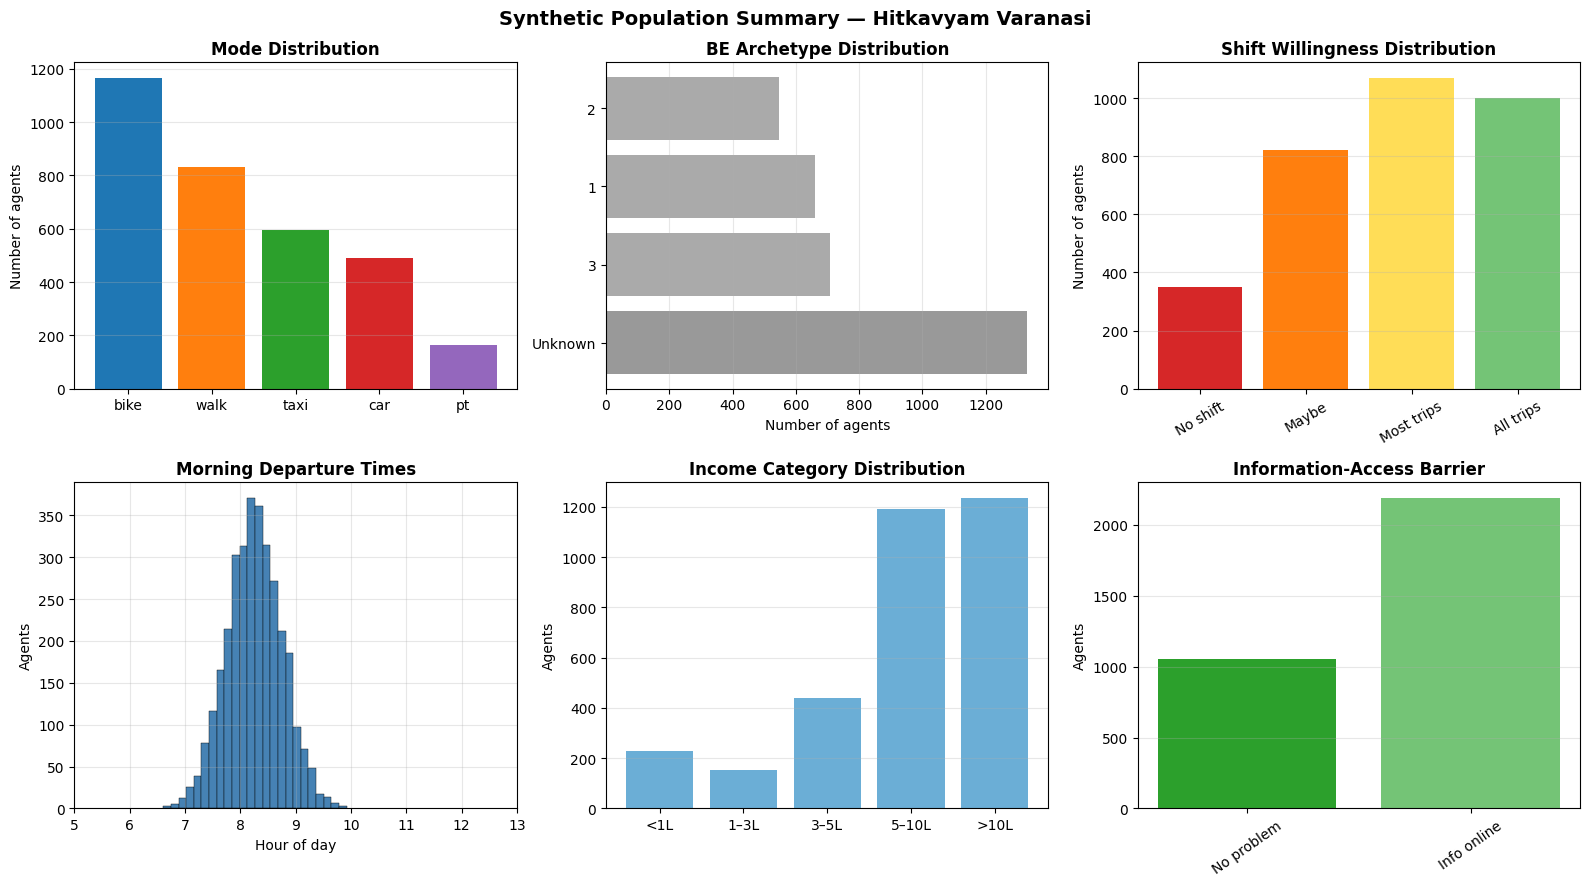

✅ Population summary chart saved.

══════════════════════════════════════════════════════════
  PHASE 2 POPULATION SUMMARY
══════════════════════════════════════════════════════════
  Total agents in plans.xml:         3,246
  With full home→work→home plan:     3,246
  With home-only plan:               0

  Factor score columns injected:     6
    Score_ITU                           → 3,246 agents have value
    Score_PEOU                          → 3,246 agents have value
    Score_PR                            → 3,246 agents have value
    Score_AW                            → 3,246 agents have value
    Score_FC                            → 3,246 agents have value
    Score_PE                            → 3,246 agents have value

  Mode breakdown:
matsim_mode
bike    1166
walk     831
taxi     595
car      492
pt       162

  Archetype breakdown:
archetype
Unknown    1332
3           707
1           660
2           547

  Copy varanasi_plans.xml to:
  src/main/resources/data/varana

In [ ]:
#!/usr/bin/env python3
"""
Hitkavyam — Phase 2: Synthetic Population Generator
Converts enriched survey data → MATSim plans.xml

Output: varanasi_plans.xml  (drop into src/main/resources/data/)
"""

import pandas as pd
import numpy as np
from xml.etree.ElementTree import Element, SubElement, ElementTree, indent
import os, warnings
warnings.filterwarnings('ignore')

np.random.seed(42)
OUT_DIR = 'outputs/'
os.makedirs(OUT_DIR, exist_ok=True)

# ═══════════════════════════════════════════════════════════════════
# CONFIG
# ═══════════════════════════════════════════════════════════════════

# MATSim mode mapping — survey label → MATSim mode string
# IPT (auto-rickshaw) mapped to 'taxi'; we'll define custom 'rikshaw'
# mode in Phase 3. Using 'taxi' keeps the network valid now.
MATSIM_MODE_MAP = {
    'Car':                  'car',
    'Two wheeler':          'bike',
    'Two wheeleer':         'bike',    # typo variant in data
    'Public transport':     'pt',
    'Company bus/ Cab':     'pt',
    'Individual Auto':      'taxi',    # IPT proxy → Phase 3 custom mode
    'Share Auto':           'taxi',
    'Walk':                 'walk',
    'Cycle':                'bike',
}

# Factor score columns — check for CFA output first, fall back to means
CFA_COL_PREFIX  = 'FS_'    # True CFA: FS_PU_ServiceQual, FS_ATT_Attitude …
MEAN_COL_PREFIX = 'Score_' # Fallback means: Score_PU, Score_ATT …

# Varanasi bounding box — coordinate sanity check
LAT_MIN, LAT_MAX = 25.10, 25.50
LNG_MIN, LNG_MAX = 82.80, 83.15

# Work activity timing (seconds from midnight)
WORK_START_MEAN  = 8.5  * 3600   # 08:30
WORK_START_STD   = 0.5  * 3600   # ±30 min
WORK_DUR_MEAN    = 8.0  * 3600   # 8-hour day
WORK_DUR_STD     = 0.75 * 3600   # ±45 min
HOME_DEPART_FLOOR = 6.0 * 3600   # Never before 06:00


# ═══════════════════════════════════════════════════════════════════
# HELPERS
# ═══════════════════════════════════════════════════════════════════

def seconds_to_hms(sec: float) -> str:
    sec = max(0, int(sec))
    h, rem = divmod(sec, 3600)
    m, s   = divmod(rem, 60)
    return f"{h:02d}:{m:02d}:{s:02d}"

def coord_valid(lat, lng) -> bool:
    return (pd.notna(lat) and pd.notna(lng) and
            LAT_MIN <= lat <= LAT_MAX and
            LNG_MIN <= lng <= LNG_MAX)

def add_xml_attr(parent_elem, name: str, value, java_type: str):
    """Add a typed MATSim person attribute."""
    attr = SubElement(parent_elem, 'attribute',
                      name=name,
                      attrib={'class': java_type})
    attr.text = str(value)

def detect_factor_cols(df) -> list:
    """Return whichever factor-score columns exist in the dataframe."""
    cfa_cols  = [c for c in df.columns if c.startswith(CFA_COL_PREFIX)]
    mean_cols = [c for c in df.columns if c.startswith(MEAN_COL_PREFIX)]
    if cfa_cols:
        print(f'  Using TRUE CFA factor scores: {cfa_cols}')
        return cfa_cols
    elif mean_cols:
        print(f'  ⚠  CFA scores absent — using mean-score proxies: {mean_cols}')
        return mean_cols
    else:
        print('  ⚠  No factor score columns found. Attributes will be sparse.')
        return []

def map_shift(val) -> int:
    """Convert shift-willingness text → ordinal 1–5."""
    v = str(val).lower()
    if   'all'    in v: return 5
    elif 'most'   in v: return 4
    elif 'few'    in v or 'some' in v: return 3
    elif 'maybe'  in v or 'not sure' in v: return 2
    elif 'not'    in v or 'never'    in v: return 1
    return 0

def map_infacc(val) -> int:
    """Convert Infacc text → severity score 0–5."""
    v = str(val).lower()
    if   'no problem'    in v: return 0
    elif 'online'        in v: return 1
    elif 'hard'          in v: return 2
    elif 'long wait'     in v or 'unreliable' in v: return 3
    elif 'far'           in v or 'difficult'  in v: return 4
    elif 'uncomfortable' in v or 'unsafe'     in v: return 5
    return 0


# ═══════════════════════════════════════════════════════════════════
# 1. LOAD DATA
# ═══════════════════════════════════════════════════════════════════

print('Loading survey data...')

# Primary: use enriched file from Phase 1 notebook (has BE archetypes + scores)
enriched_path = OUT_DIR + 'ind_with_BE_archetype.csv'
raw_ind_path  = 'VNS_SURVEY_IND.csv'

if os.path.exists(enriched_path):
    ind = pd.read_csv(enriched_path)
    print(f'  Loaded enriched IND: {len(ind):,} respondents (from Phase 1 output)')
else:
    ind = pd.read_csv(raw_ind_path)
    print(f'  ⚠  Enriched file not found — loading raw IND: {len(ind):,} respondents')
    print('     Run Phase 1 notebook first to get BE archetypes & factor scores.')

od = pd.read_csv('VNS_SURVEY_OD.csv')
print(f'  Loaded OD: {len(od):,} trip records')


# ═══════════════════════════════════════════════════════════════════
# 2. BUILD WORK-TRIP LOOKUP (one work trip per respondent)
# ═══════════════════════════════════════════════════════════════════

print('\nBuilding work-trip index...')

od_work = (od[od['Purpose'].str.lower().str.contains('work', na=False)]
              .dropna(subset=['Dest_Lat','Dest_Lng'])
              .drop_duplicates('ResID')
              [['ResID','Dest_Lat','Dest_Lng','Distance_km','Travel_Time_Min']]
              .set_index('ResID'))

print(f'  Work trips with destination coords: {len(od_work):,}')

factor_cols = detect_factor_cols(ind)


# ═══════════════════════════════════════════════════════════════════
# 3. BUILD AGENT RECORDS
# ═══════════════════════════════════════════════════════════════════

print('\nBuilding agent records...')

agents = []
skipped_no_home = 0
skipped_no_dest = 0

for _, row in ind.iterrows():
    res_id = int(row['ResID'])

    # ── Home coordinates (respondent location) ──────────────────────
    home_lat = row.get('Latitude_WGS84',  np.nan)
    home_lng = row.get('Longitude_WGS84', np.nan)

    if not coord_valid(home_lat, home_lng):
        skipped_no_home += 1
        continue

    # ── Work destination (from OD file) ─────────────────────────────
    if res_id in od_work.index:
        w = od_work.loc[res_id]
        work_lat = w['Dest_Lat']
        work_lng = w['Dest_Lng']
        travel_min = w.get('Travel_Time_Min', 30)
        dist_km    = w.get('Distance_km',    None)
        has_work_trip = coord_valid(work_lat, work_lng)
    else:
        has_work_trip = False

    if not has_work_trip:
        # Agents without a known work destination get a home-based plan
        # (single 24h home activity). This is valid MATSim — they simply
        # don't travel. We still inject all their psychological attributes.
        work_lat, work_lng = np.nan, np.nan
        travel_min = 30
        dist_km    = None
        skipped_no_dest += 1

    # ── Generate departure & return times ──────────────────────────
    work_start_sec  = np.random.normal(WORK_START_MEAN, WORK_START_STD)
    travel_sec      = travel_min * 60
    depart_home_sec = max(HOME_DEPART_FLOOR,
                          work_start_sec - travel_sec - 300)  # 5 min buffer
    work_end_sec    = work_start_sec + np.random.normal(WORK_DUR_MEAN, WORK_DUR_STD)
    depart_work_sec = work_end_sec + 300  # 5 min buffer before return leg

    # ── Mode mapping ───────────────────────────────────────────────
    survey_mode   = str(row.get('Mode_to_Work', 'walk'))
    matsim_mode   = MATSIM_MODE_MAP.get(survey_mode, 'walk')

    # ── Archetype ──────────────────────────────────────────────────
    # Try multiple possible column names from Phase 1 output
    archetype = (row.get('BE_Archetype_Name')
                 or row.get('BE_Archetype')
                 or row.get('BE_Archetype_Cluster')
                 or 'Unknown')

    # ── Shift willingness ──────────────────────────────────────────
    shift_ord = row.get('Shift_Ord', None)
    if pd.isna(shift_ord) and 'Shift' in row:
        shift_ord = map_shift(row['Shift'])
    shift_ord = int(shift_ord) if pd.notna(shift_ord) else 0

    # ── Infacc barrier ─────────────────────────────────────────────
    infacc_num = row.get('Infacc_Num', None)
    if pd.isna(infacc_num) and 'Infacc' in row:
        infacc_num = map_infacc(row['Infacc'])
    infacc_num = int(infacc_num) if pd.notna(infacc_num) else 0

    # ── Income group ───────────────────────────────────────────────
    inc_raw = str(row.get('Income', 'Unknown'))
    if   'Cat1' in inc_raw or '< 1' in inc_raw:   income_cat = 1
    elif 'Cat2' in inc_raw or '1,00' in inc_raw:  income_cat = 2
    elif 'Cat3' in inc_raw or '3,00' in inc_raw:  income_cat = 3
    elif 'Cat4' in inc_raw or '5,00' in inc_raw:  income_cat = 4
    elif 'Cat5' in inc_raw or '10 L' in inc_raw:  income_cat = 5
    else:                                           income_cat = 0

    # ── Factor scores ──────────────────────────────────────────────
    factor_vals = {}
    for col in factor_cols:
        val = row.get(col, np.nan)
        if pd.notna(val):
            factor_vals[col] = float(round(val, 4))

    agents.append({
        'res_id':         res_id,
        'home_lat':       float(home_lat),
        'home_lng':       float(home_lng),
        'work_lat':       float(work_lat)  if has_work_trip else None,
        'work_lng':       float(work_lng)  if has_work_trip else None,
        'has_work_trip':  has_work_trip,
        'depart_home':    depart_home_sec,
        'work_start':     work_start_sec,
        'work_end':       work_end_sec,
        'depart_work':    depart_work_sec,
        'matsim_mode':    matsim_mode,
        'survey_mode':    survey_mode,
        'archetype':      str(archetype),
        'shift_ord':      shift_ord,
        'infacc_num':     infacc_num,
        'income_cat':     income_cat,
        'dist_km':        dist_km,
        'factor_vals':    factor_vals,
    })

print(f'\n  Agents with full plans (home + work):  {sum(a["has_work_trip"] for a in agents):,}')
print(f'  Agents with home-only plans:           {skipped_no_dest:,}')
print(f'  Dropped (no valid home coordinates):   {skipped_no_home:,}')
print(f'  ─────────────────────────────────────')
print(f'  Total agents to write:                 {len(agents):,}')


# ═══════════════════════════════════════════════════════════════════
# 4. BUILD plans.xml
# ═══════════════════════════════════════════════════════════════════

print('\nBuilding plans.xml ...')

root = Element('population')
root.set('desc', 'Varanasi MaaS Survey Population — Hitkavyam')

for ag in agents:
    # ── <person> ──────────────────────────────────────────────────
    person_elem = SubElement(root, 'person', id=str(ag['res_id']))

    # ── <attributes> — psychological + spatial profile ────────────
    attrs_elem = SubElement(person_elem, 'attributes')

    # Core identity attributes
    add_xml_attr(attrs_elem, 'BE_Archetype',        ag['archetype'],     'java.lang.String')
    add_xml_attr(attrs_elem, 'Survey_Mode',         ag['survey_mode'],   'java.lang.String')
    add_xml_attr(attrs_elem, 'MATSim_Mode_Pref',    ag['matsim_mode'],   'java.lang.String')
    add_xml_attr(attrs_elem, 'Income_Category',     ag['income_cat'],    'java.lang.Integer')
    add_xml_attr(attrs_elem, 'Shift_Willingness',   ag['shift_ord'],     'java.lang.Integer')
    add_xml_attr(attrs_elem, 'InfoAccess_Barrier',  ag['infacc_num'],    'java.lang.Integer')
    add_xml_attr(attrs_elem, 'Has_Work_Trip',
                 str(ag['has_work_trip']).lower(),                       'java.lang.Boolean')

    if ag['dist_km'] is not None:
        add_xml_attr(attrs_elem, 'Work_Distance_km',
                     round(float(ag['dist_km']), 2),                     'java.lang.Double')

    # TAM+TPB factor scores — key predictors for Phase 3 scoring
    for col, val in ag['factor_vals'].items():
        # Normalise column name: 'FS_PU_ServiceQual' → 'FS_PU'
        short_name = col.replace('Score_', 'FS_').split('_')[0:2]
        attr_name  = '_'.join(short_name)
        add_xml_attr(attrs_elem, attr_name, val, 'java.lang.Double')

    # ── <plan> ────────────────────────────────────────────────────
    plan_elem = SubElement(person_elem, 'plan', selected='yes')

    if ag['has_work_trip']:
        # FULL PLAN: home → work → home
        # Activity 1: Home (morning)
        SubElement(plan_elem, 'activity', {
            'type':     'home',
            'x':        str(round(ag['home_lng'], 6)),
            'y':        str(round(ag['home_lat'], 6)),
            'end_time': seconds_to_hms(ag['depart_home'])
        })
        # Leg 1: commute to work
        SubElement(plan_elem, 'leg', mode=ag['matsim_mode'])
        # Activity 2: Work
        SubElement(plan_elem, 'activity', {
            'type':       'work',
            'x':          str(round(ag['work_lng'], 6)),
            'y':          str(round(ag['work_lat'], 6)),
            'start_time': seconds_to_hms(ag['work_start']),
            'end_time':   seconds_to_hms(ag['work_end'])
        })
        # Leg 2: return home
        SubElement(plan_elem, 'leg', mode=ag['matsim_mode'])
        # Activity 3: Home (evening)
        SubElement(plan_elem, 'activity', {
            'type': 'home',
            'x':    str(round(ag['home_lng'], 6)),
            'y':    str(round(ag['home_lat'], 6)),
        })
    else:
        # HOME-ONLY PLAN: agent stays home all day
        SubElement(plan_elem, 'activity', {
            'type': 'home',
            'x':    str(round(ag['home_lng'], 6)),
            'y':    str(round(ag['home_lat'], 6)),
        })

# Pretty-print the XML tree
indent(root, space='  ')

out_xml = OUT_DIR + 'varanasi_plans.xml'
with open(out_xml, 'wb') as f:
    f.write(b'<?xml version="1.0" encoding="UTF-8"?>\n')
    f.write(b'<!DOCTYPE population SYSTEM '
            b'"http://www.matsim.org/files/dtd/population_v6.dtd">\n')
    ElementTree(root).write(f, encoding='utf-8', xml_declaration=False)

print(f'\n✅ plans.xml written → {out_xml}')


# ═══════════════════════════════════════════════════════════════════
# 5. POPULATION SUMMARY REPORT
# ═══════════════════════════════════════════════════════════════════

import matplotlib.pyplot as plt

ag_df = pd.DataFrame(agents)

fig, axes = plt.subplots(2, 3, figsize=(16, 9))
fig.suptitle('Synthetic Population Summary — Hitkavyam Varanasi',
             fontsize=14, fontweight='bold')

# 1. Mode distribution
ax = axes[0, 0]
mode_counts = ag_df['matsim_mode'].value_counts()
ax.bar(mode_counts.index, mode_counts.values,
       color=['#1f77b4','#ff7f0e','#2ca02c','#d62728','#9467bd'])
ax.set_title('Mode Distribution', fontweight='bold')
ax.set_ylabel('Number of agents')
ax.grid(axis='y', alpha=0.3)

# 2. BE Archetype distribution
ax = axes[0, 1]
arch_colors = {'Ghat_Core':'#e41a1c','Transitional':'#ff7f00',
               'Peripheral':'#4daf4a','Fringe':'#984ea3','Unknown':'#999'}
arch_counts = ag_df['archetype'].value_counts()
colors_list = [arch_colors.get(a,'#aaa') for a in arch_counts.index]
ax.barh(arch_counts.index, arch_counts.values, color=colors_list)
ax.set_title('BE Archetype Distribution', fontweight='bold')
ax.set_xlabel('Number of agents')
ax.grid(axis='x', alpha=0.3)

# 3. Shift willingness
ax = axes[0, 2]
shift_label = {0:'?', 1:'No shift', 2:'Unlikely', 3:'Maybe', 4:'Most trips', 5:'All trips'}
shift_counts = ag_df['shift_ord'].value_counts().sort_index()
ax.bar([shift_label.get(k, k) for k in shift_counts.index], shift_counts.values,
       color=['#d62728','#ff7f0e','#ffdd57','#74c476','#2ca02c','#aaa'])
ax.set_title('Shift Willingness Distribution', fontweight='bold')
ax.set_ylabel('Number of agents')
ax.tick_params(axis='x', rotation=30)
ax.grid(axis='y', alpha=0.3)

# 4. Departure time histogram
ax = axes[1, 0]
depart_hrs = ag_df[ag_df['has_work_trip']]['depart_home'] / 3600
ax.hist(depart_hrs, bins=24, color='steelblue', edgecolor='k', linewidth=0.3)
ax.set_title('Morning Departure Times', fontweight='bold')
ax.set_xlabel('Hour of day'); ax.set_ylabel('Agents')
ax.set_xlim(5, 13); ax.grid(alpha=0.3)

# 5. Income distribution
ax = axes[1, 1]
inc_label = {0:'Unknown', 1:'<1L', 2:'1–3L', 3:'3–5L', 4:'5–10L', 5:'>10L'}
inc_counts = ag_df['income_cat'].value_counts().sort_index()
ax.bar([inc_label.get(k, k) for k in inc_counts.index], inc_counts.values,
       color='#6baed6')
ax.set_title('Income Category Distribution', fontweight='bold')
ax.set_ylabel('Agents'); ax.grid(axis='y', alpha=0.3)

# 6. InfoAccess barrier
ax = axes[1, 2]
infacc_label = {0:'No problem', 1:'Info online', 2:'Hard to find',
                3:'Long wait', 4:'Too far', 5:'Uncomfortable'}
inf_counts = ag_df['infacc_num'].value_counts().sort_index()
bar_c = ['#2ca02c','#74c476','#ffdd57','#ff7f0e','#d62728','#9467bd']
ax.bar([infacc_label.get(k, k) for k in inf_counts.index],
       inf_counts.values, color=bar_c[:len(inf_counts)])
ax.set_title('Information-Access Barrier', fontweight='bold')
ax.set_ylabel('Agents')
ax.tick_params(axis='x', rotation=35); ax.grid(axis='y', alpha=0.3)

fig.tight_layout()
fig.savefig(OUT_DIR + 'population_summary.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Population summary chart saved.')

# Print text summary
print('\n══════════════════════════════════════════════════════════')
print('  PHASE 2 POPULATION SUMMARY')
print('══════════════════════════════════════════════════════════')
print(f'  Total agents in plans.xml:         {len(agents):,}')
print(f'  With full home→work→home plan:     {ag_df["has_work_trip"].sum():,}')
print(f'  With home-only plan:               {(~ag_df["has_work_trip"]).sum():,}')
print(f'\n  Factor score columns injected:     {len(factor_cols)}')
for col in factor_cols:
    valid = ag_df['factor_vals'].apply(lambda d: col in d).sum()
    print(f'    {col:<35} → {valid:,} agents have value')
print(f'\n  Mode breakdown:')
print(ag_df['matsim_mode'].value_counts().to_string())
print(f'\n  Archetype breakdown:')
print(ag_df['archetype'].value_counts().to_string())
print('\n  Copy varanasi_plans.xml to:')
print('  src/main/resources/data/varanasi_plans.xml')

In [ ]:
import pandas as pd
import os

# Load your refined dataset
df = pd.read_csv('ind_with_BE_archetype.csv')

# Group the raw sub-variables into their theoretical constructs
constructs = {
    'ITU':  ['ITU1', 'ITU2'],
    'PEOU': ['PEOU1', 'PEOU2'],
    'PR':   ['PR1', 'PR2', 'PR3', 'PR4'],
    'AW':   ['AW1', 'AW2', 'AW3'],
    'FC':   ['FC1', 'FC2'],
    'PE':   ['PE1', 'PE2', 'PE3']
}

# Calculate the mean score across the grouped questions
for construct, cols in constructs.items():
    df[f'Score_{construct}'] = df[cols].mean(axis=1)

# Ensure the outputs directory exists and save the file inside it!
os.makedirs('outputs/', exist_ok=True)
df.to_csv('outputs/ind_with_BE_archetype.csv', index=False)

print("✅ Successfully generated aggregated scores!")
print("Constructs ready for MATSim:", [f'Score_{k}' for k in constructs.keys()])

✅ Successfully generated aggregated scores!
Constructs ready for MATSim: ['Score_ITU', 'Score_PEOU', 'Score_PR', 'Score_AW', 'Score_FC', 'Score_PE']


In [ ]:
from google.colab import files
print("Forcing download of the freshly generated plans.xml...")
files.download('outputs/varanasi_plans.xml')

Forcing download of the freshly generated plans.xml...


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
!pip install h3 pydeck pandas matplotlib --quiet

import os, gzip
import xml.etree.ElementTree as ET
import pandas as pd
import numpy as np
import h3
import matplotlib.pyplot as plt

# Handle H3 version differences gracefully
H3_TO_CELL = h3.latlng_to_cell if hasattr(h3, 'latlng_to_cell') else h3.geo_to_h3
H3_TO_LATLNG = h3.cell_to_latlng if hasattr(h3, 'cell_to_latlng') else h3.h3_to_geo

print("🚀 Streaming output_plans.xml.gz to extract Equilibrium modes...")

agents = []
current_agent = {}
in_selected_plan = False

# Stream the zipped file
with gzip.open('output_plans.xml.gz', 'rt', encoding='utf-8') as f:
    context = ET.iterparse(f, events=('start', 'end'))

    for event, elem in context:
        if event == 'start' and elem.tag == 'plan':
            in_selected_plan = (elem.get('selected') == 'yes')
            if in_selected_plan: current_agent['_modes'] = []

        elif event == 'end':
            if elem.tag == 'attribute':
                name = elem.get('name')
                if name in ['BE_Archetype']: current_agent[name] = elem.text
                elif name in ['FS_ITU', 'FS_FC', 'FS_AW']: current_agent[name] = float(elem.text) if elem.text else 0.0
                elem.clear()

            elif elem.tag == 'activity' and in_selected_plan:
                if elem.get('type') == 'home' and 'home_x' not in current_agent:
                    current_agent['home_x'], current_agent['home_y'] = float(elem.get('x')), float(elem.get('y'))
                elem.clear()

            elif elem.tag == 'leg' and in_selected_plan:
                current_agent['_modes'].append(elem.get('mode'))
                elem.clear()

            elif elem.tag == 'plan':
                if in_selected_plan:
                    modes = current_agent.pop('_modes', [])
                    # The mode they used on their outbound commute at Iteration 50
                    current_agent['Equilibrium_Mode'] = modes[0] if modes else 'Unknown'
                in_selected_plan = False
                elem.clear()

            elif elem.tag == 'person':
                current_agent['id'] = elem.get('id')
                agents.append(current_agent.copy())
                current_agent.clear()
                elem.clear()

df_agents = pd.DataFrame(agents)
print(f"✅ Extracted true equilibrium state for {len(df_agents)} commuters.")
display(df_agents.head())

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 28.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.3/11.3 MB 55.0 MB/s eta 0:00:00
🚀 Streaming output_plans.xml.gz to extract Equilibrium modes...
✅ Extracted true equilibrium state for 3246 commuters.


,BE_Archetype,FS_AW,FS_FC,FS_ITU,home_x,home_y,Equilibrium_Mode,id
0,1,3.6667,4.0,4.0,82.976984,25.309855,pt,1
1,3,3.6667,4.0,4.0,82.946537,25.368966,pt,10
2,Unknown,3.3333,2.0,2.0,83.011328,25.329765,taxi,100
3,1,3.6667,4.0,4.0,82.998043,25.349816,bike,1000
4,Unknown,3.6667,4.0,4.0,83.008990,25.324289,car,1001



══════════════════════════════════════════════════════════
  SPATIAL MISMATCH: GHAT-CORE VS. FRINGE (ITERATION 50)
══════════════════════════════════════════════════════════
🏘️ Ghat-Core PT Equilibrium Share: 39.1% (n=660)
🏘️ Industrial-Fringe PT Equilibrium Share: 0.0% (n=0)
   Gap: 39.1 pts.


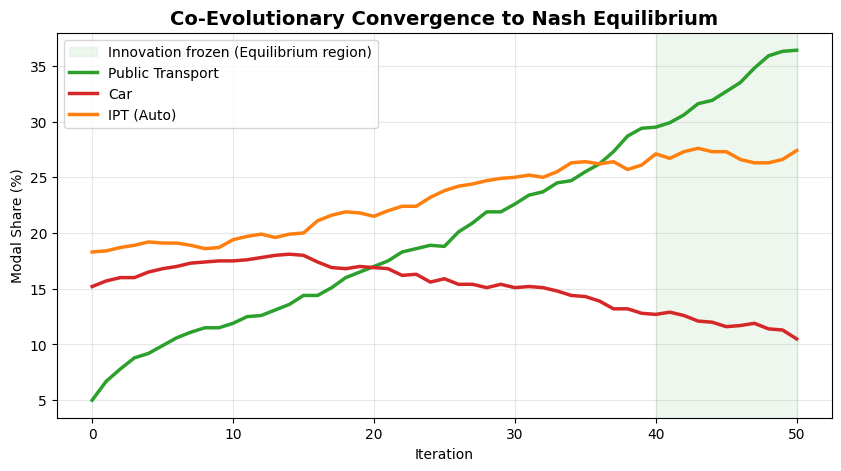

In [ ]:
# 1. Headline Finding: Ghat-Core vs. Fringe Spatial Mismatch
print("\n══════════════════════════════════════════════════════════")
print("  SPATIAL MISMATCH: GHAT-CORE VS. FRINGE (ITERATION 50)")
print("══════════════════════════════════════════════════════════")

df_agents['BE_Archetype'] = df_agents['BE_Archetype'].astype(str)
gc = df_agents[df_agents['BE_Archetype'].str.contains('1|Ghat', case=False, na=False)]
fr = df_agents[df_agents['BE_Archetype'].str.contains('4|Fringe', case=False, na=False)]

gc_pt = (gc['Equilibrium_Mode'] == 'pt').mean() * 100 if len(gc) > 0 else 0
fr_pt = (fr['Equilibrium_Mode'] == 'pt').mean() * 100 if len(fr) > 0 else 0

print(f"🏘️ Ghat-Core PT Equilibrium Share: {gc_pt:.1f}% (n={len(gc)})")
print(f"🏘️ Industrial-Fringe PT Equilibrium Share: {fr_pt:.1f}% (n={len(fr)})")
print(f"   Gap: {abs(gc_pt - fr_pt):.1f} pts.")

# 2. Convergence Graph
try:
    ms = pd.read_csv('modal_share.csv')
    fig, ax = plt.subplots(figsize=(10, 5))
    ax.axvspan(40, 50, color='#2ca02c', alpha=0.08, label='Innovation frozen (Equilibrium region)')

    for col, label, color in [('pt_share', 'Public Transport', '#2ca02c'),
                              ('car_share', 'Car', '#d62728'),
                              ('ipt_share', 'IPT (Auto)', '#ff7f0e')]:
        ax.plot(ms['iteration'], ms[col]*100, linewidth=2.5, label=label, color=color)

    ax.set_title('Co-Evolutionary Convergence to Nash Equilibrium', fontsize=14, fontweight='bold')
    ax.set_xlabel('Iteration'); ax.set_ylabel('Modal Share (%)')
    ax.legend(); ax.grid(alpha=0.3)
    plt.savefig('nash_equilibrium.png', dpi=300, bbox_inches='tight')
    plt.show()
except FileNotFoundError:
    print("⚠️ modal_share.csv not found for graphing.")

In [ ]:
import pydeck as pdk
from IPython.display import display, HTML
import math

print("🚀 Building Confidence-Aware 3D Pydeck Visualization...")

dfh = df_agents.dropna(subset=['home_x', 'home_y', 'Equilibrium_Mode']).copy()
dfh['hex_id'] = dfh.apply(lambda r: H3_TO_CELL(r['home_y'], r['home_x'], 8), axis=1)

# Aggregate into H3 Hexbins
hex_stats = dfh.groupby('hex_id').apply(lambda g: pd.Series({
    'total_agents': len(g),
    'pt_users': (g['Equilibrium_Mode'] == 'pt').sum(),
    'car_users': (g['Equilibrium_Mode'] == 'car').sum(),
    'dominant_archetype': g['BE_Archetype'].mode().iloc[0] if not g['BE_Archetype'].empty else 'Unknown'
})).reset_index()

hex_stats['pt_adoption_rate'] = (hex_stats['pt_users'] / hex_stats['total_agents'] * 100).round(1)

# Map hex centers
latlng = hex_stats['hex_id'].apply(H3_TO_LATLNG)
hex_stats['lat'] = latlng.apply(lambda t: t[0])
hex_stats['lng'] = latlng.apply(lambda t: t[1])

# Color scaling based on adoption (Red to Green) and opacity based on sample size confidence
max_agents = hex_stats['total_agents'].max()
def get_color(row):
    norm = min(max(row['pt_adoption_rate'] / 100.0, 0), 1)
    r, g = int(255 * (1 - norm)), int(255 * norm)
    conf = min(1.0, math.sqrt(row['total_agents'] / max(max_agents, 1)))
    alpha = int(60 + 195 * conf) # Low sample size = more transparent
    return [r, g, 60, alpha]

hex_stats['color'] = hex_stats.apply(get_color, axis=1)

# Pydeck Layering
layer = pdk.Layer(
    'H3HexagonLayer',
    hex_stats,
    pickable=True, stroked=True, filled=True, extruded=True,
    get_hexagon='hex_id', get_fill_color='color',
    get_elevation='pt_adoption_rate', elevation_scale=30,
)

view_state = pdk.ViewState(latitude=25.3176, longitude=82.9739, zoom=11.5, pitch=45, bearing=15)

r = pdk.Deck(
    layers=[layer], initial_view_state=view_state, map_style='mapbox://styles/mapbox/dark-v10',
    tooltip={
        'html': '<b>Archetype:</b> {dominant_archetype}<br/>'
                '<b>Agents in Zone:</b> {total_agents}<br/>'
                '<b>Equilibrium PT Adoption:</b> {pt_adoption_rate}%',
        'style': {'color':'white','backgroundColor':'#222222'}
    }
)

html_file = 'varanasi_equilibrium_3d.html'
r.to_html(html_file)
display(HTML(f"<a href='{html_file}' target='_blank'>Open 3D Equilibrium Map</a>"))

🚀 Building Confidence-Aware 3D Pydeck Visualization...


/tmp/ipykernel_11435/604787636.py:11: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  hex_stats = dfh.groupby('hex_id').apply(lambda g: pd.Series({


<IPython.core.display.Javascript object>